# 1 - Simple Sentiment Analysis

In this series we'll be building a machine learning model to detect sentiment (i.e. detect if a sentence is positive or negative) using PyTorch and TorchText. This will be done on movie reviews, using the [IMDb dataset](http://ai.stanford.edu/~amaas/data/sentiment/).

In this first notebook, we'll start very simple to understand the general concepts whilst not really caring about good results. Further notebooks will build on this knowledge and we'll actually get good results.

### Introduction

We'll be using a **recurrent neural network** (RNN) as they are commonly used in analysing sequences. An RNN takes in sequence of words, $X=\{x_1, ..., x_T\}$, one at a time, and produces a _hidden state_, $h$, for each word. We use the RNN _recurrently_ by feeding in the current word $x_t$ as well as the hidden state from the previous word, $h_{t-1}$, to produce the next hidden state, $h_t$.

$$h_t = \text{RNN}(x_t, h_{t-1})$$

Once we have our final hidden state, $h_T$, (from feeding in the last word in the sequence, $x_T$) we feed it through a linear layer, $f$, (also known as a fully connected layer), to receive our predicted sentiment, $\hat{y} = f(h_T)$.

Below shows an example sentence, with the RNN predicting zero, which indicates a negative sentiment. The RNN is shown in orange and the linear layer shown in silver. Note that we use the same RNN for every word, i.e. it has the same parameters. The initial hidden state, $h_0$, is a tensor initialized to all zeros.

![](https://github.com/bentrevett/pytorch-sentiment-analysis/blob/master/assets/sentiment1.png?raw=1)

**Note:** some layers and steps have been omitted from the diagram, but these will be explained later.

## Preparing Data

One of the main concepts of TorchText is the `Field`. These define how your data should be processed. In our sentiment classification task the data consists of both the raw string of the review and the sentiment, either "pos" or "neg".

The parameters of a `Field` specify how the data should be processed.

We use the `TEXT` field to define how the review should be processed, and the `LABEL` field to process the sentiment.

Our `TEXT` field has `tokenize='spacy'` as an argument. This defines that the "tokenization" (the act of splitting the string into discrete "tokens") should be done using the [spaCy](https://spacy.io) tokenizer. If no `tokenize` argument is passed, the default is simply splitting the string on spaces. We also need to specify a `tokenizer_language` which tells torchtext which spaCy model to use. We use the `en_core_web_sm` model which has to be downloaded with `python -m spacy download en_core_web_sm` before you run this notebook!

`LABEL` is defined by a `LabelField`, a special subset of the `Field` class specifically used for handling labels. We will explain the `dtype` argument later.

For more on `Fields`, go [here](https://github.com/pytorch/text/blob/master/torchtext/data/field.py).

We also set the random seeds for reproducibility.

In [1]:
!pip install torchtext==0.4.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.3 MB/s eta 0:00:00


In [2]:
import torch
from torchtext import data

SEED = 1234

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

TEXT = data.Field(tokenize = 'spacy',
                  tokenizer_language = 'en_core_web_sm',
                  include_lengths = True,
                  pad_first=True)
LABEL = data.LabelField(dtype = torch.float)

Another handy feature of TorchText is that it has support for common datasets used in natural language processing (NLP).

The following code automatically downloads the IMDb dataset and splits it into the canonical train/test splits as `torchtext.datasets` objects. It process the data using the `Fields` we have previously defined. The IMDb dataset consists of 50,000 movie reviews, each marked as being a positive or negative review.

In [3]:
from torchtext import datasets

train_data, test_data = datasets.IMDB.splits(TEXT, LABEL)

downloading aclImdb_v1.tar.gz


aclImdb_v1.tar.gz: 100%|██████████| 84.1M/84.1M [00:56<00:00, 1.49MB/s]


We can see how many examples are in each split by checking their length.

In [4]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 25000
Number of testing examples: 25000


We can also check an example.

In [5]:
print(vars(train_data.examples[0]))

{'text': ['Five', 'years', 'on', 'from', 'the', 'Tenko', 'survivors', 'returning', 'home', ',', 'and', 'from', 'Marion', "'s", 'double', '-', 'edged', '"', 'Well', 'that', "'s", 'that".<br', '/><br', '/>It', "'s", 'now', '1950', ':', 'reunion', 'time', '.', 'The', 'gang', "'s", 'all', 'here', ':', 'Marion', ',', 'Bea', ',', 'Ulrica', ',', 'Kate', ',', 'Dorothy', ',', 'Christina', ',', 'Dominica', ',', 'and', 'latecomers', 'Maggie', 'and', 'Alice', '.', 'The', 'story', 'that', 'unfolds', 'is', 'a', 'beaut', ':', 'as', 'perfectly', 'written', 'and', 'acted', ',', 'and', 'as', 'thought', '-', 'provoking', 'and', 'moving', ',', 'as', 'the', 'original', 'series.<br', '/><br', '/>All', 'the', 'questions', 'left', 'hanging', 'at', 'the', 'end', 'of', 'the', 'series', 'are', 'neatly', 'answered', 'here', '.', 'From', 'Marion', "'s", 'family', 'to', 'Joss', "'s", 'health', 'centre', ',', 'everything', 'has', 'changed', 'in', 'five', 'years', ',', 'and', 'not', 'everything', 'has', 'changed', 'f

The IMDb dataset only has train/test splits, so we need to create a validation set. We can do this with the `.split()` method.

By default this splits 70/30, however by passing a `split_ratio` argument, we can change the ratio of the split, i.e. a `split_ratio` of 0.8 would mean 80% of the examples make up the training set and 20% make up the validation set.

We also pass our random seed to the `random_state` argument, ensuring that we get the same train/validation split each time.

In [6]:
import random

train_data, valid_data = train_data.split(random_state = random.seed(SEED))

Again, we'll view how many examples are in each split.

In [7]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 17500
Number of validation examples: 7500
Number of testing examples: 25000


Next, we have to build a _vocabulary_. This is a effectively a look up table where every unique word in your data set has a corresponding _index_ (an integer).

We do this as our machine learning model cannot operate on strings, only numbers. Each _index_ is used to construct a _one-hot_ vector for each word. A one-hot vector is a vector where all of the elements are 0, except one, which is 1, and dimensionality is the total number of unique words in your vocabulary, commonly denoted by $V$.

![](https://github.com/bentrevett/pytorch-sentiment-analysis/blob/master/assets/sentiment5.png?raw=1)

The number of unique words in our training set is over 100,000, which means that our one-hot vectors will have over 100,000 dimensions! This will make training slow and possibly won't fit onto your GPU (if you're using one).

There are two ways effectively cut down our vocabulary, we can either only take the top $n$ most common words or ignore words that appear less than $m$ times. We'll do the former, only keeping the top 25,000 words.

What do we do with words that appear in examples but we have cut from the vocabulary? We replace them with a special _unknown_ or `<unk>` token. For example, if the sentence was "This film is great and I love it" but the word "love" was not in the vocabulary, it would become "This film is great and I `<unk>` it".

The following builds the vocabulary, only keeping the most common `max_size` tokens.

In [8]:
MAX_VOCAB_SIZE = 25_000

TEXT.build_vocab(train_data, max_size = MAX_VOCAB_SIZE)
LABEL.build_vocab(train_data)

Why do we only build the vocabulary on the training set? When testing any machine learning system you do not want to look at the test set in any way. We do not include the validation set as we want it to reflect the test set as much as possible.

In [9]:
print(f"Unique tokens in TEXT vocabulary: {len(TEXT.vocab)}")
print(f"Unique tokens in LABEL vocabulary: {len(LABEL.vocab)}")

Unique tokens in TEXT vocabulary: 25002
Unique tokens in LABEL vocabulary: 2


Why is the vocab size 25002 and not 25000? One of the addition tokens is the `<unk>` token and the other is a `<pad>` token.

When we feed sentences into our model, we feed a _batch_ of them at a time, i.e. more than one at a time, and all sentences in the batch need to be the same size. Thus, to ensure each sentence in the batch is the same size, any shorter than the longest within the batch are padded.

![](https://github.com/bentrevett/pytorch-sentiment-analysis/blob/master/assets/sentiment6.png?raw=1)

We can also view the most common words in the vocabulary and their frequencies.

In [10]:
print(TEXT.vocab.freqs.most_common(20))

[('the', 201913), (',', 191740), ('.', 165524), ('and', 109360), ('a', 109288), ('of', 100465), ('to', 93674), ('is', 76290), ('in', 61371), ('I', 54147), ('it', 53835), ('that', 49160), ('"', 43923), ("'s", 43223), ('this', 42153), ('-', 37649), ('/><br', 35465), ('was', 35090), ('as', 30266), ('with', 30065)]


We can also see the vocabulary directly using either the `stoi` (**s**tring **to** **i**nt) or `itos` (**i**nt **to**  **s**tring) method.

In [11]:
print(TEXT.vocab.itos[:10])

['<unk>', '<pad>', 'the', ',', '.', 'and', 'a', 'of', 'to', 'is']


We can also check the labels, ensuring 0 is for negative and 1 is for positive.

In [12]:
print(LABEL.vocab.stoi)

defaultdict(None, {'neg': 0, 'pos': 1})


In [13]:
TEXT.__dict__

{'sequential': True,
 'use_vocab': True,
 'init_token': None,
 'eos_token': None,
 'unk_token': '<unk>',
 'fix_length': None,
 'dtype': torch.int64,
 'preprocessing': None,
 'postprocessing': None,
 'lower': False,
 'tokenizer_args': ('spacy', 'en_core_web_sm'),
 'tokenize': functools.partial(<function _spacy_tokenize at 0x79dcbda1c040>, spacy=<spacy.lang.en.English object at 0x79dcad479050>),
 'include_lengths': True,
 'batch_first': False,
 'pad_token': '<pad>',
 'pad_first': True,
 'truncate_first': False,
 'stop_words': None,
 'is_target': False,
 'vocab': <torchtext.vocab.Vocab at 0x79dca5df6910>}

The final step of preparing the data is creating the iterators. We iterate over these in the training/evaluation loop, and they return a batch of examples (indexed and converted into tensors) at each iteration.

We'll use a `BucketIterator` which is a special type of iterator that will return a batch of examples where each example is of a similar length, minimizing the amount of padding per example.

We also want to place the tensors returned by the iterator on the GPU (if you're using one). PyTorch handles this using `torch.device`, we then pass this device to the iterator.

In [14]:
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

## Build the Model

The next stage is building the model that we'll eventually train and evaluate.

There is a small amount of boilerplate code when creating models in PyTorch, note how our `RNN` class is a sub-class of `nn.Module` and the use of `super`.

Within the `__init__` we define the _layers_ of the module. Our three layers are an _embedding_ layer, our RNN, and a _linear_ layer. All layers have their parameters initialized to random values, unless explicitly specified.

The embedding layer is used to transform our sparse one-hot vector (sparse as most of the elements are 0) into a dense embedding vector (dense as the dimensionality is a lot smaller and all the elements are real numbers). This embedding layer is simply a single fully connected layer. As well as reducing the dimensionality of the input to the RNN, there is the theory that words which have similar impact on the sentiment of the review are mapped close together in this dense vector space. For more information about word embeddings, see [here](https://monkeylearn.com/blog/word-embeddings-transform-text-numbers/).

The RNN layer is our RNN which takes in our dense vector and the previous hidden state $h_{t-1}$, which it uses to calculate the next hidden state, $h_t$.

![](https://github.com/bentrevett/pytorch-sentiment-analysis/blob/master/assets/sentiment7.png?raw=1)

Finally, the linear layer takes the final hidden state and feeds it through a fully connected layer, $f(h_T)$, transforming it to the correct output dimension.

The `forward` method is called when we feed examples into our model.

Each batch, `text`, is a tensor of size _**[sentence length, batch size]**_. That is a batch of sentences, each having each word converted into a one-hot vector.

You may notice that this tensor should have another dimension due to the one-hot vectors, however PyTorch conveniently stores a one-hot vector as it's index value, i.e. the tensor representing a sentence is just a tensor of the indexes for each token in that sentence. The act of converting a list of tokens into a list of indexes is commonly called *numericalizing*.

The input batch is then passed through the embedding layer to get `embedded`, which gives us a dense vector representation of our sentences. `embedded` is a tensor of size _**[sentence length, batch size, embedding dim]**_.

`embedded` is then fed into the RNN. In some frameworks you must feed the initial hidden state, $h_0$, into the RNN, however in PyTorch, if no initial hidden state is passed as an argument it defaults to a tensor of all zeros.

The RNN returns 2 tensors, `output` of size _**[sentence length, batch size, hidden dim]**_ and `hidden` of size _**[1, batch size, hidden dim]**_. `output` is the concatenation of the hidden state from every time step, whereas `hidden` is simply the final hidden state. We verify this using the `assert` statement. Note the `squeeze` method, which is used to remove a dimension of size 1.

Finally, we feed the last hidden state, `hidden`, through the linear layer, `fc`, to produce a prediction.

In [15]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim):

        super().__init__()

        self.embedding = nn.Embedding(input_dim, embedding_dim)

        self.rnn = nn.RNN(embedding_dim, hidden_dim)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text, text_lengths):
        #text = [sent len, batch size]

        embedded = self.embedding(text)
        #embedded = [sent len, batch size, emb dim]

        output, hidden = self.rnn(embedded)
        #output = [sent len, batch size, hid dim]
        #hidden = [1, batch size, hid dim]

        #assert torch.equal(output[-1,:,:], hidden.squeeze(0))

        return self.fc(hidden.squeeze(0))

We now create an instance of our RNN class.

The input dimension is the dimension of the one-hot vectors, which is equal to the vocabulary size.

The embedding dimension is the size of the dense word vectors. This is usually around 50-250 dimensions, but depends on the size of the vocabulary.

The hidden dimension is the size of the hidden states. This is usually around 100-500 dimensions, but also depends on factors such as on the vocabulary size, the size of the dense vectors and the complexity of the task.

The output dimension is usually the number of classes, however in the case of only 2 classes the output value is between 0 and 1 and thus can be 1-dimensional, i.e. a single scalar real number.

In [16]:
INPUT_DIM = len(TEXT.vocab)
EMBEDDING_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 1

model = RNN(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM)

Let's also create a function that will tell us how many trainable parameters our model has so we can compare the number of parameters across different models.

In [17]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 2,592,105 trainable parameters


## 🏁 RUN FROM HERE: Train the Model

### MOVED THE results DECLARATION HERE SO IT IS ONLY RUN ONCE!

In [18]:
# Declare only once where the result data will be saved
results = {
    "SGD": {
        "train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [],
        "test_loss": None, "test_acc": None
    },
    "Adam": {
        "train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [],
        "test_loss": None, "test_acc": None
    },
    "Adagrad": {
        "train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [],
        "test_loss": None, "test_acc": None
    },
}

#### ❗️❗️DECLARE THE OPTIMIZER TYPE HERE:

Now we'll set up the training and then train the model.

First, we'll create an optimizer. This is the algorithm we use to update the parameters of the module. Here, we'll use _stochastic gradient descent_ (SGD). The first argument is the parameters will be updated by the optimizer, the second is the learning rate, i.e. how much we'll change the parameters by when we do a parameter update.

In [61]:
import torch.optim as optim

#modified by dymasius
#optimizer = optim.SGD(model.parameters(), lr=1e-3)

optimizer_type = "Adagrad"  # Change this to "Adam" or "Adagrad" as needed
learning_rate = 1e-3

if optimizer_type == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
elif optimizer_type == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
elif optimizer_type == "Adagrad":
    optimizer = optim.Adagrad(model.parameters(), lr=learning_rate)

Next, we'll define our loss function. In PyTorch this is commonly called a criterion.

The loss function here is _binary cross entropy with logits_.

Our model currently outputs an unbound real number. As our labels are either 0 or 1, we want to restrict the predictions to a number between 0 and 1. We do this using the _sigmoid_ or _logit_ functions.

We then use this this bound scalar to calculate the loss using binary cross entropy.

The `BCEWithLogitsLoss` criterion carries out both the sigmoid and the binary cross entropy steps.

In [62]:
criterion = nn.BCEWithLogitsLoss()

Using `.to`, we can place the model and the criterion on the GPU (if we have one).

In [63]:
model = model.to(device)
criterion = criterion.to(device)

Our criterion function calculates the loss, however we have to write our function to calculate the accuracy.

This function first feeds the predictions through a sigmoid layer, squashing the values between 0 and 1, we then round them to the nearest integer. This rounds any value greater than 0.5 to 1 (a positive sentiment) and the rest to 0 (a negative sentiment).

We then calculate how many rounded predictions equal the actual labels and average it across the batch.

In [64]:
def binary_accuracy(preds, y):
    """
    Returns accuracy per batch, i.e. if you get 8/10 right, this returns 0.8, NOT 8
    """

    #round predictions to the closest integer
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float() #convert into float for division
    acc = correct.sum() / len(correct)
    return acc

The `train` function iterates over all examples, one batch at a time.

`model.train()` is used to put the model in "training mode", which turns on _dropout_ and _batch normalization_. Although we aren't using them in this model, it's good practice to include it.

For each batch, we first zero the gradients. Each parameter in a model has a `grad` attribute which stores the gradient calculated by the `criterion`. PyTorch does not automatically remove (or "zero") the gradients calculated from the last gradient calculation, so they must be manually zeroed.

We then feed the batch of sentences, `batch.text`, into the model. Note, you do not need to do `model.forward(batch.text)`, simply calling the model works. The `squeeze` is needed as the predictions are initially size _**[batch size, 1]**_, and we need to remove the dimension of size 1 as PyTorch expects the predictions input to our criterion function to be of size _**[batch size]**_.

The loss and accuracy are then calculated using our predictions and the labels, `batch.label`, with the loss being averaged over all examples in the batch.

We calculate the gradient of each parameter with `loss.backward()`, and then update the parameters using the gradients and optimizer algorithm with `optimizer.step()`.

The loss and accuracy is accumulated across the epoch, the `.item()` method is used to extract a scalar from a tensor which only contains a single value.

Finally, we return the loss and accuracy, averaged across the epoch. The `len` of an iterator is the number of batches in the iterator.

You may recall when initializing the `LABEL` field, we set `dtype=torch.float`. This is because TorchText sets tensors to be `LongTensor`s by default, however our criterion expects both inputs to be `FloatTensor`s. Setting the `dtype` to be `torch.float`, did this for us. The alternative method of doing this would be to do the conversion inside the `train` function by passing `batch.label.float()` instad of `batch.label` to the criterion.

In [65]:
def train(model, iterator, optimizer, criterion):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for batch in iterator:

        optimizer.zero_grad()

        text, text_lengths = batch.text

        predictions = model(text, text_lengths).squeeze(1)

        loss = criterion(predictions, batch.label)

        acc = binary_accuracy(predictions, batch.label)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

`evaluate` is similar to `train`, with a few modifications as you don't want to update the parameters when evaluating.

`model.eval()` puts the model in "evaluation mode", this turns off _dropout_ and _batch normalization_. Again, we are not using them in this model, but it is good practice to include them.

No gradients are calculated on PyTorch operations inside the `with no_grad()` block. This causes less memory to be used and speeds up computation.

The rest of the function is the same as `train`, with the removal of `optimizer.zero_grad()`, `loss.backward()` and `optimizer.step()`, as we do not update the model's parameters when evaluating.

In [66]:
def evaluate(model, iterator, criterion):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for batch in iterator:
            text, text_lengths = batch.text

            predictions = model(text, text_lengths).squeeze(1)

            loss = criterion(predictions, batch.label)

            acc = binary_accuracy(predictions, batch.label)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

We'll also create a function to tell us how long an epoch takes to compare training times between models.

In [67]:
import time

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

## 📣TRAINING PART BELOW:

### ❗️CHANGE NUMBER OF EPOCH BELOW

In [68]:
N_EPOCHS = 20
best_valid_loss = float('inf')

### 📣 PRINT PARAMETERS BEFORE RUNNING

In [69]:
print(f"INFO: You are using this optimizer type: {optimizer_type}")
print(f"INFO: You are using this EPOCH Number: {N_EPOCHS}")
print(f"INFO: You are using this best valid loss: {best_valid_loss}")

INFO: You are using this optimizer type: Adagrad
INFO: You are using this EPOCH Number: 20
INFO: You are using this best valid loss: inf


We then train the model through multiple epochs, an epoch being a complete pass through all examples in the training and validation sets.

At each epoch, if the validation loss is the best we have seen so far, we'll save the parameters of the model and then after training has finished we'll use that model on the test set.

### ❗️DECLARE ONLY ONCE FOR results BELOW:

In [70]:
# Declare only once where the result data will be saved
#results = {
#    "SGD": {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": []},
#    "Adam": {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": []},
#    "Adagrad": {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": []},
#}

In [71]:
#for epoch in range(N_EPOCHS):

#    start_time = time.time()

#    train_loss, train_acc = train(model, train_iterator, optimizer, criterion)
#    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion)

#    end_time = time.time()

#    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#    if valid_loss < best_valid_loss:
#        best_valid_loss = valid_loss
#        torch.save(model.state_dict(), 'tut1-model.pt')

#    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
#    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
#    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

In [72]:
for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # Save metrics
    results[optimizer_type]["train_loss"].append(train_loss)
    results[optimizer_type]["valid_loss"].append(valid_loss)
    results[optimizer_type]["train_acc"].append(train_acc)
    results[optimizer_type]["valid_acc"].append(valid_acc)

    # Save the best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), f"{optimizer_type}_model.pt")

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} | Val. Acc: {valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 0m 3s
	Train Loss: 0.416 | Train Acc: 82.44%
	 Val. Loss: 0.579 | Val. Acc: 72.39%
Epoch: 02 | Epoch Time: 0m 3s
	Train Loss: 0.403 | Train Acc: 82.90%
	 Val. Loss: 0.576 | Val. Acc: 72.00%
Epoch: 03 | Epoch Time: 0m 3s
	Train Loss: 0.396 | Train Acc: 83.13%
	 Val. Loss: 0.575 | Val. Acc: 72.73%
Epoch: 04 | Epoch Time: 0m 2s
	Train Loss: 0.392 | Train Acc: 83.51%
	 Val. Loss: 0.574 | Val. Acc: 72.85%
Epoch: 05 | Epoch Time: 0m 2s
	Train Loss: 0.389 | Train Acc: 83.59%
	 Val. Loss: 0.572 | Val. Acc: 72.70%
Epoch: 06 | Epoch Time: 0m 2s
	Train Loss: 0.388 | Train Acc: 83.65%
	 Val. Loss: 0.574 | Val. Acc: 72.98%
Epoch: 07 | Epoch Time: 0m 2s
	Train Loss: 0.382 | Train Acc: 84.00%
	 Val. Loss: 0.574 | Val. Acc: 73.08%
Epoch: 08 | Epoch Time: 0m 2s
	Train Loss: 0.382 | Train Acc: 84.25%
	 Val. Loss: 0.573 | Val. Acc: 72.84%
Epoch: 09 | Epoch Time: 0m 2s
	Train Loss: 0.380 | Train Acc: 84.22%
	 Val. Loss: 0.571 | Val. Acc: 72.91%
Epoch: 10 | Epoch Time: 0m 3s
	Train 

You may have noticed the loss is not really decreasing and the accuracy is poor. This is due to several issues with the model which we'll improve in the next notebook.

Finally, the metric we actually care about, the test loss and accuracy, which we get from our parameters that gave us the best validation loss.

## 📣TESTING PART BELOW:

In [73]:
#model.load_state_dict(torch.load('tut1-model.pt'))

#test_loss, test_acc = evaluate(model, test_iterator, criterion)

#print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

In [74]:
model.load_state_dict(torch.load(f"{optimizer_type}_model.pt"))
test_loss, test_acc = evaluate(model, test_iterator, criterion)

# Save test results
results[optimizer_type]["test_loss"] = test_loss
results[optimizer_type]["test_acc"] = test_acc

print(f"{optimizer_type} Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%")

<ipython-input-74-65073e4998e4>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{optimizer_type}_model.pt"))


Adagrad Test Loss: 0.572 | Test Acc: 73.28%


## 📝SAVE RESULTS BELOW FOR OPTIMIZER:

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
!ls "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/"

 Assignment						 model_results_saved_14JAN2025.csv
'Assignment 1 Report.gdoc'				 model_results_saved_14JAN2025.gsheet
 Assignment_1_Simple_Sentiment_Analysis.ipynb		 Results
 Dymasius_Assignment_1_Simple_Sentiment_Analysis.ipynb	 results_saved_14012025.csv
 epoch_results_saved_14JAN2025.csv			 results_saved_14JAN2025.csv
'model_results_saved_14JAN2025 (1).gsheet'		 results_saved_16JAN2025.csv


In [77]:
import pandas as pd

results_saved_16012025 = results #CHANGE HERE

# Convert results dictionary to a pandas DataFrame
results_flattened = []
for optimizer, metrics in results_saved_16012025.items(): #CHANGE HERE
    results_flattened.append({
        "Optimizer": optimizer,
        "Train Loss": metrics.get("train_loss", []),
        "Valid Loss": metrics.get("valid_loss", []),
        "Train Accuracy": metrics.get("train_acc", []),
        "Valid Accuracy": metrics.get("valid_acc", []),
        "Test Loss": metrics.get("test_loss"),
        "Test Accuracy": metrics.get("test_acc")
    })

df = pd.DataFrame(results_flattened)

# Save the DataFrame to a CSV file
csv_filename = "results_saved_16JAN2025.csv" #CHANGE HERE
df.to_csv(csv_filename, index=False)

print(f"INFO: Results saved to {csv_filename}") #SAVED TO CSV

from google.colab import files

# DOWNLOAD the CSV file
files.download(csv_filename)


# Step 2: Define the path in Google Drive
drive_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/results_saved_16JAN2025.csv" #CHANGE HERE

# Step 3: Save the CSV file
df.to_csv(drive_path, index=False)

print(f"INFO: Results saved to {drive_path}")

INFO: Results saved to results_saved_16JAN2025.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

INFO: Results saved to /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/results_saved_16JAN2025.csv


In [78]:
results

{'SGD': {'train_loss': [0.695257755526661,
   0.6927247510774293,
   0.6914518906252227,
   0.690439792227571,
   0.6895843659439226,
   0.688790109470813,
   0.6880725234964468,
   0.6874776380340548,
   0.6867993819887621,
   0.6862220574904533,
   0.6855854096203825,
   0.6850790923094228,
   0.6845377178957862,
   0.683987052988832,
   0.6834469494158334,
   0.683044462961002,
   0.6825090455312799,
   0.6820418110294063,
   0.6815412377354002,
   0.6811004931474254],
  'valid_loss': [0.6943782264903441,
   0.6936030195931256,
   0.6928806754492097,
   0.6924516639467013,
   0.6918260894589505,
   0.6914102233062356,
   0.6909686923027039,
   0.6905021606865576,
   0.6902862681170642,
   0.6892922318587869,
   0.6890717280113091,
   0.68870078103017,
   0.6883075439323814,
   0.6879786828816947,
   0.6873269530676179,
   0.6869777728945522,
   0.686618237172143,
   0.6861673684443458,
   0.6859165157301951,
   0.6854103399535357],
  'train_acc': [0.5020529197080292,
   0.5173602060

## 📣PLOTTING THE RESULT:

In [84]:
# import matplotlib.pyplot as plt

# # Plot training and validation loss
# plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
# for optimizer in results:
#     plt.plot(results[optimizer]["train_loss"], linestyle='--', label=f"{optimizer} Train Loss")  # Dotted line
#     plt.plot(results[optimizer]["valid_loss"], linestyle='-', label=f"{optimizer} Valid Loss")  # Solid line

# plt.title("Training and Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside
# plt.tight_layout()  # Adjust layout to fit everything
# plt.show()

# # Plot training and validation accuracy
# plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
# for optimizer in results:
#     plt.plot(results[optimizer]["train_acc"], linestyle='--', label=f"{optimizer} Train Accuracy")  # Dotted line
#     plt.plot(results[optimizer]["valid_acc"], linestyle='-', label=f"{optimizer} Valid Accuracy")  # Solid line

# plt.title("Training and Validation Accuracy")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside
# plt.tight_layout()  # Adjust layout to fit everything
# plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Loss plot saved locally to ./NLPA1_16JAN2025_1A_Loss.png
INFO: Loss plot saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_1A_Loss.png


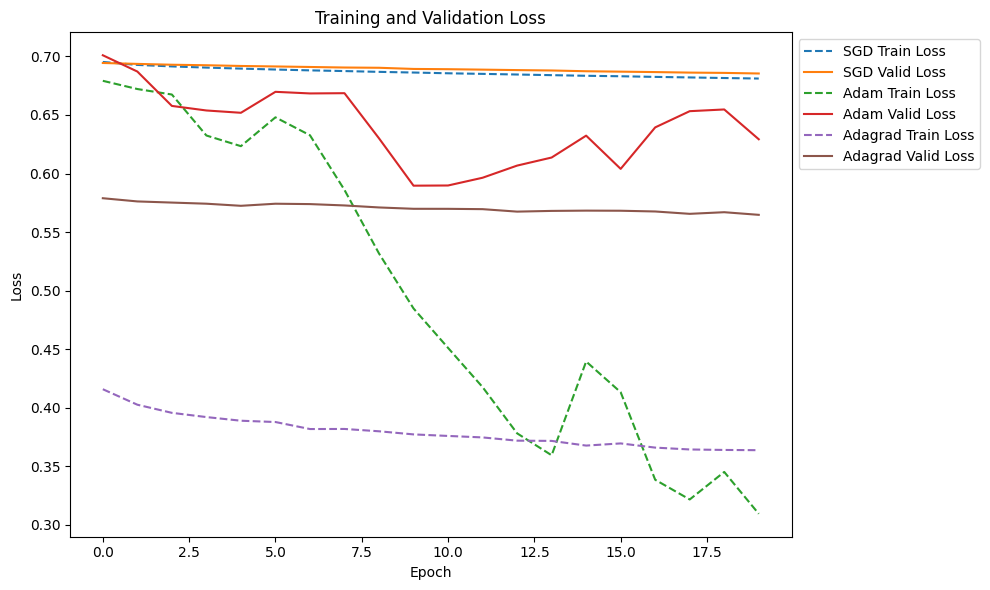

INFO: Accuracy plot saved locally to ./NLPA1_16JAN2025_1B_Acc.png
INFO: Accuracy plot saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_1B_Acc.png


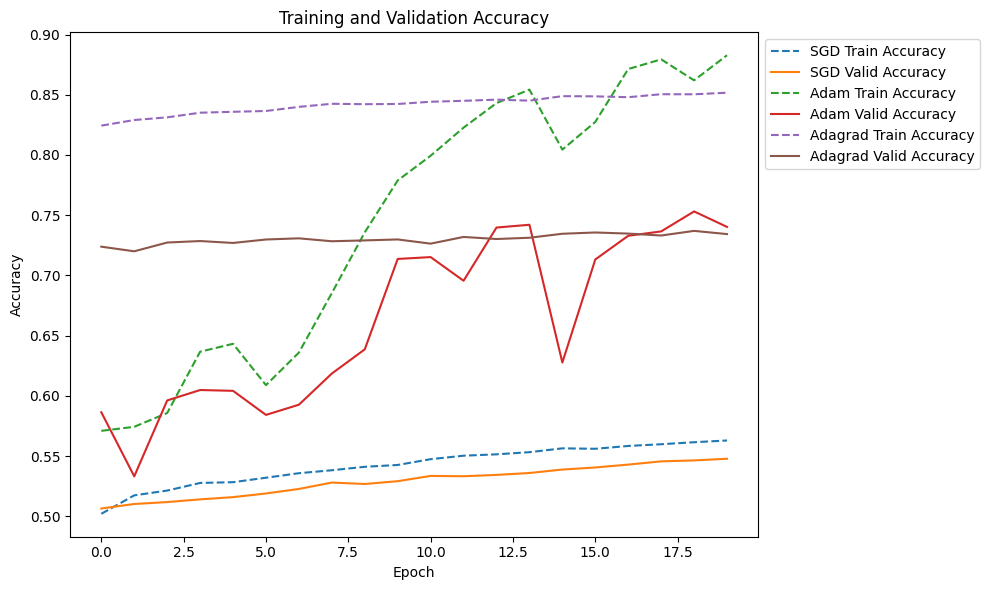

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
import matplotlib.pyplot as plt
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Define file names and paths
image_filename_loss = "NLPA1_16JAN2025_1A_Loss.png"
image_filename_acc = "NLPA1_16JAN2025_1B_Acc.png"
gdrive_save_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/"
local_save_path = "./"

# Ensure Google Drive directory exists
os.makedirs(gdrive_save_path, exist_ok=True)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
for optimizer in results:
    plt.plot(results[optimizer]["train_loss"], linestyle='--', label=f"{optimizer} Train Loss")
    plt.plot(results[optimizer]["valid_loss"], linestyle='-', label=f"{optimizer} Valid Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Save the loss plot
loss_local_path = os.path.join(local_save_path, image_filename_loss)
loss_drive_path = os.path.join(gdrive_save_path, image_filename_loss)
plt.savefig(loss_local_path)
plt.savefig(loss_drive_path)
print(f"INFO: Loss plot saved locally to {loss_local_path}")
print(f"INFO: Loss plot saved to Google Drive at {loss_drive_path}")
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
for optimizer in results:
    plt.plot(results[optimizer]["train_acc"], linestyle='--', label=f"{optimizer} Train Accuracy")
    plt.plot(results[optimizer]["valid_acc"], linestyle='-', label=f"{optimizer} Valid Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

# Save the accuracy plot
acc_local_path = os.path.join(local_save_path, image_filename_acc)
acc_drive_path = os.path.join(gdrive_save_path, image_filename_acc)
plt.savefig(acc_local_path)
plt.savefig(acc_drive_path)
print(f"INFO: Accuracy plot saved locally to {acc_local_path}")
print(f"INFO: Accuracy plot saved to Google Drive at {acc_drive_path}")
plt.show()

# Download both plots locally
files.download(loss_local_path)
files.download(acc_local_path)

In [80]:
# Assuming `results` is your dictionary with optimizer results
optimizers_with_test_results = [opt for opt in results if "test_loss" in results[opt] and "test_acc" in results[opt]]

# Now calculate test losses and accuracies
test_losses = [results[opt]["test_loss"] if results[opt]["test_loss"] is not None else 0 for opt in optimizers_with_test_results]
test_accuracies = [results[opt]["test_acc"] * 100 if results[opt]["test_acc"] is not None else 0 for opt in optimizers_with_test_results]

print(f"Test Losses: {test_losses}")
print(f"Test Accuracies: {test_accuracies}")

Test Losses: [0.6829541557280304, 0.5930154604070327, 0.5719512111847967]
Test Accuracies: [56.01102941481354, 71.0877557544757, 73.27925192425623]


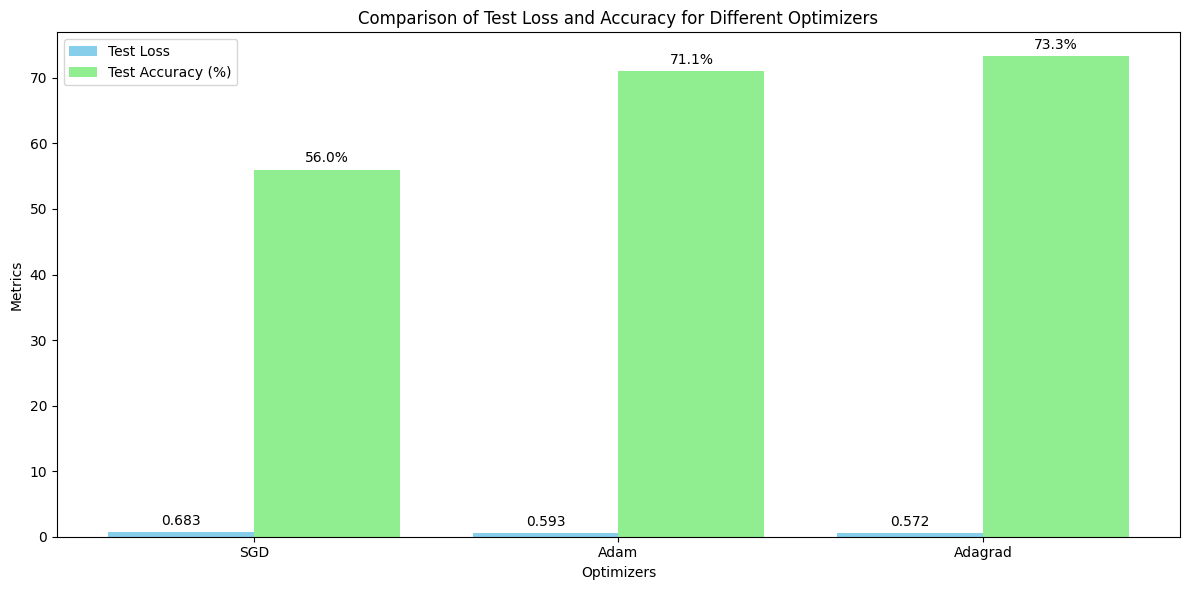

In [81]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Handle missing test results
# test_losses = [results[opt]["test_loss"] if results[opt]["test_loss"] is not None else 0 for opt in optimizers_with_test_results]
# test_accuracies = [results[opt]["test_acc"] * 100 if results[opt]["test_acc"] is not None else 0 for opt in optimizers_with_test_results]

# # Create subplots for side-by-side comparison
# x = np.arange(len(optimizers_with_test_results))  # x positions for bars
# width = 0.4  # Width of bars

# fig, ax = plt.subplots(figsize=(12, 6))

# # Plot Test Loss as bars
# loss_bars = ax.bar(x - width / 2, test_losses, width, label="Test Loss", color="skyblue")

# # Plot Test Accuracy as bars
# accuracy_bars = ax.bar(x + width / 2, test_accuracies, width, label="Test Accuracy (%)", color="lightgreen")

# # Add labels, title, and legend
# ax.set_xlabel("Optimizers")
# ax.set_ylabel("Metrics")
# ax.set_title("Comparison of Test Loss and Accuracy for Different Optimizers")
# ax.set_xticks(x)
# ax.set_xticklabels(optimizers_with_test_results)
# ax.legend()

# # Annotate bars with values
# for bar in loss_bars:
#     ax.annotate(f'{bar.get_height():.3f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
#                 xytext=(0, 3),  # Offset for text
#                 textcoords="offset points",
#                 ha="center", va="bottom")

# for bar in accuracy_bars:
#     ax.annotate(f'{bar.get_height():.1f}%',
#                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
#                 xytext=(0, 3),
#                 textcoords="offset points",
#                 ha="center", va="bottom")

# plt.tight_layout()
# plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Image saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_1C_Comparison.png
INFO: Image saved locally as NLPA1_16JAN2025_1C_Comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

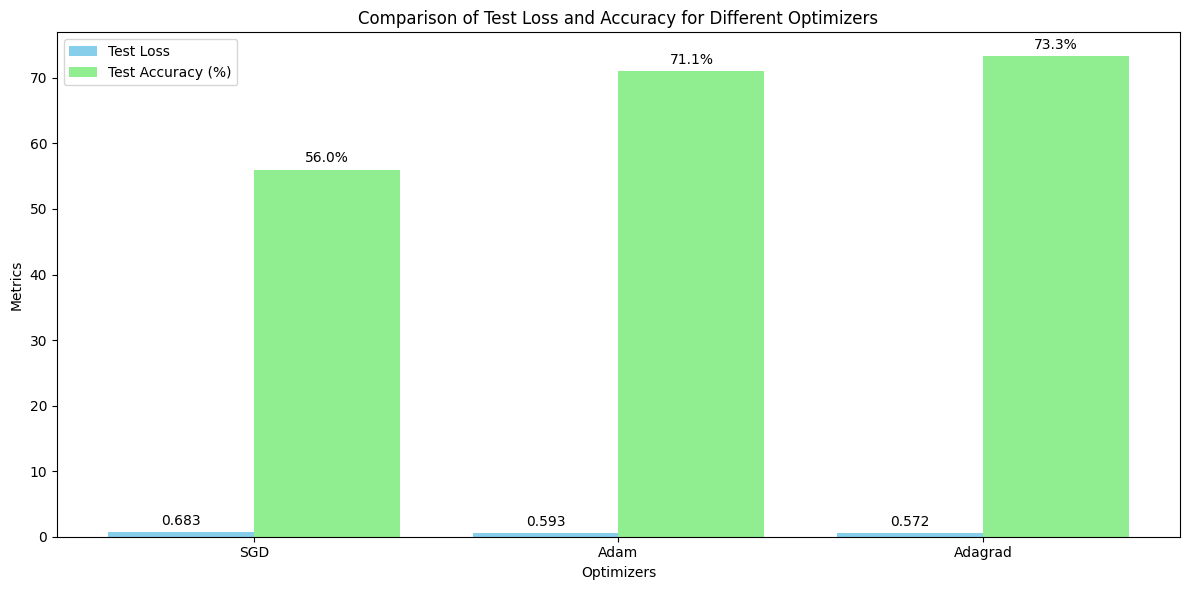

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Handle missing test results
test_losses = [results[opt]["test_loss"] if results[opt]["test_loss"] is not None else 0 for opt in optimizers_with_test_results]
test_accuracies = [results[opt]["test_acc"] * 100 if results[opt]["test_acc"] is not None else 0 for opt in optimizers_with_test_results]

# Create subplots for side-by-side comparison
x = np.arange(len(optimizers_with_test_results))  # x positions for bars
width = 0.4  # Width of bars

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Test Loss as bars
loss_bars = ax.bar(x - width / 2, test_losses, width, label="Test Loss", color="skyblue")

# Plot Test Accuracy as bars
accuracy_bars = ax.bar(x + width / 2, test_accuracies, width, label="Test Accuracy (%)", color="lightgreen")

# Add labels, title, and legend
ax.set_xlabel("Optimizers")
ax.set_ylabel("Metrics")
ax.set_title("Comparison of Test Loss and Accuracy for Different Optimizers")
ax.set_xticks(x)
ax.set_xticklabels(optimizers_with_test_results)
ax.legend()

# Annotate bars with values
for bar in loss_bars:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),  # Offset for text
                textcoords="offset points",
                ha="center", va="bottom")

for bar in accuracy_bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom")

plt.tight_layout()

# Save to Google Drive
drive_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/"
os.makedirs(drive_path, exist_ok=True)
file_name_drive = os.path.join(drive_path, "NLPA1_16JAN2025_1C_Comparison.png")
plt.savefig(file_name_drive, format="png")
print(f"INFO: Image saved to Google Drive at {file_name_drive}")

# Save locally
file_name_local = "NLPA1_16JAN2025_1C_Comparison.png"
plt.savefig(file_name_local, format="png")
print(f"INFO: Image saved locally as {file_name_local}")

# Download the local file
files.download(file_name_local)

# 🏁STEP 3: VARYING THE EPOCH NUMBER WITH ADAM OPTIMIZER

## 📣NOW USING ADAM BUT DIFFERENT NUMBER OF EPOCH

In [86]:
import torch.optim as optim
import time

# Results dictionary for Step 3
epoch_results = {
    5: {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [], "test_loss": None, "test_acc": None},
    10: {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [], "test_loss": None, "test_acc": None},
    20: {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [], "test_loss": None, "test_acc": None},
    50: {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [], "test_loss": None, "test_acc": None},
}

# Experiment settings
epoch_settings = [5, 10, 20, 50]
learning_rate = 1e-3

# Loop through different epoch settings
for n_epochs in epoch_settings:
    print(f"\nINFO: Experimenting with {n_epochs} epochs using Adam optimizer...\n")

    # Reinitialize model and optimizer
    model = RNN(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)  # Ensure model is reinitialized
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) #using ADAM HERE!

    # Track best validation loss
    best_valid_loss = float('inf')

    for epoch in range(n_epochs):
        start_time = time.time()

        # Train and evaluate
        train_loss, train_acc = train(model, train_iterator, optimizer, criterion)
        valid_loss, valid_acc = evaluate(model, valid_iterator, criterion)

        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        # Save best model for this epoch setting
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), f"adam_{n_epochs}_epochs_model.pt")

        # Record results for this epoch
        epoch_results[n_epochs]["train_loss"].append(train_loss)
        epoch_results[n_epochs]["valid_loss"].append(valid_loss)
        epoch_results[n_epochs]["train_acc"].append(train_acc)
        epoch_results[n_epochs]["valid_acc"].append(valid_acc)

        print(f"Epoch: {epoch+1}/{n_epochs} | Epoch Time: {epoch_mins}m {epoch_secs}s")
        print(f"\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%")
        print(f"\t Val. Loss: {valid_loss:.3f} | Val. Acc: {valid_acc*100:.2f}%")

    # Load the best model for this epoch setting and evaluate on test data
    model.load_state_dict(torch.load(f"adam_{n_epochs}_epochs_model.pt"))
    test_loss, test_acc = evaluate(model, test_iterator, criterion)

    # Save test results
    epoch_results[n_epochs]["test_loss"] = test_loss
    epoch_results[n_epochs]["test_acc"] = test_acc

    print(f"Best Model Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%")


INFO: Experimenting with 5 epochs using Adam optimizer...

Epoch: 1/5 | Epoch Time: 0m 3s
	Train Loss: 0.684 | Train Acc: 55.96%
	 Val. Loss: 0.685 | Val. Acc: 53.98%
Epoch: 2/5 | Epoch Time: 0m 2s
	Train Loss: 0.645 | Train Acc: 63.09%
	 Val. Loss: 0.672 | Val. Acc: 57.11%
Epoch: 3/5 | Epoch Time: 0m 3s
	Train Loss: 0.604 | Train Acc: 67.13%
	 Val. Loss: 0.596 | Val. Acc: 69.28%
Epoch: 4/5 | Epoch Time: 0m 2s
	Train Loss: 0.575 | Train Acc: 69.53%
	 Val. Loss: 0.660 | Val. Acc: 59.89%
Epoch: 5/5 | Epoch Time: 0m 2s
	Train Loss: 0.545 | Train Acc: 72.00%
	 Val. Loss: 0.656 | Val. Acc: 61.50%


<ipython-input-86-40fd0779f65a>:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"adam_{n_epochs}_epochs_model.pt"))


Best Model Test Loss: 0.605 | Test Acc: 68.45%

INFO: Experimenting with 10 epochs using Adam optimizer...

Epoch: 1/10 | Epoch Time: 0m 3s
	Train Loss: 0.678 | Train Acc: 56.94%
	 Val. Loss: 0.669 | Val. Acc: 57.84%
Epoch: 2/10 | Epoch Time: 0m 3s
	Train Loss: 0.669 | Train Acc: 57.85%
	 Val. Loss: 0.694 | Val. Acc: 51.02%
Epoch: 3/10 | Epoch Time: 0m 3s
	Train Loss: 0.696 | Train Acc: 51.16%
	 Val. Loss: 0.695 | Val. Acc: 51.46%
Epoch: 4/10 | Epoch Time: 0m 3s
	Train Loss: 0.689 | Train Acc: 54.22%
	 Val. Loss: 0.711 | Val. Acc: 51.30%
Epoch: 5/10 | Epoch Time: 0m 3s
	Train Loss: 0.681 | Train Acc: 56.07%
	 Val. Loss: 0.682 | Val. Acc: 56.37%
Epoch: 6/10 | Epoch Time: 0m 3s
	Train Loss: 0.640 | Train Acc: 63.15%
	 Val. Loss: 0.621 | Val. Acc: 66.02%
Epoch: 7/10 | Epoch Time: 0m 3s
	Train Loss: 0.612 | Train Acc: 66.65%
	 Val. Loss: 0.639 | Val. Acc: 63.54%
Epoch: 8/10 | Epoch Time: 0m 3s
	Train Loss: 0.537 | Train Acc: 74.38%
	 Val. Loss: 0.580 | Val. Acc: 70.98%
Epoch: 9/10 | Epoch 

### 📝SAVE RESULTS BELOW FOR EPOCH EXPERIMENTS:

In [87]:
epoch_results_saved_16JAN2025 = epoch_results #CHANGE HERE

# Flatten epoch_results dictionary
epoch_results_flattened = []
for n_epochs, metrics in epoch_results_saved_16JAN2025.items(): #CHANGE
    epoch_results_flattened.append({
        "Epochs": n_epochs,
        "Train Loss": metrics.get("train_loss", []),
        "Valid Loss": metrics.get("valid_loss", []),
        "Train Accuracy": metrics.get("train_acc", []),
        "Valid Accuracy": metrics.get("valid_acc", []),
        "Test Loss": metrics.get("test_loss"),
        "Test Accuracy": metrics.get("test_acc")
    })

# Convert to a pandas DataFrame
df_epoch_results = pd.DataFrame(epoch_results_flattened)

# Save to local CSV file
epoch_csv_filename = "epoch_results_saved_16JAN2025.csv" #CHANGE
df_epoch_results.to_csv(epoch_csv_filename, index=False)
print(f"INFO: Epoch results saved locally to {epoch_csv_filename}")

# Download the local CSV file
files.download(epoch_csv_filename)

# Save to Google Drive
drive_path_epoch = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/epoch_results_saved_16JAN2025.csv" #CHANGE
df_epoch_results.to_csv(drive_path_epoch, index=False)
print(f"INFO: Epoch results saved to Google Drive at {drive_path_epoch}")

INFO: Epoch results saved locally to epoch_results_saved_16JAN2025.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

INFO: Epoch results saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/epoch_results_saved_16JAN2025.csv


## 📣PLOT THE EPOCH TRAIN RESULT

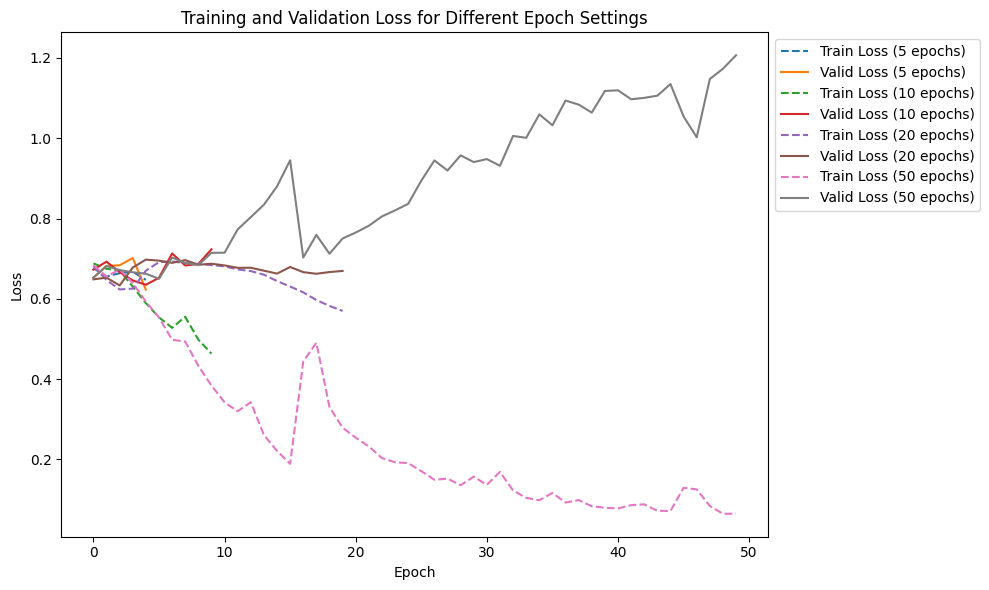

In [ ]:
# plt.figure(figsize=(10, 6))

# for n_epochs in epoch_results:
#     plt.plot(epoch_results[n_epochs]["train_loss"], linestyle='--', label=f"Train Loss ({n_epochs} epochs)")
#     plt.plot(epoch_results[n_epochs]["valid_loss"], linestyle='-', label=f"Valid Loss ({n_epochs} epochs)")

# plt.title("Training and Validation Loss for Different Epoch Settings")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the graph
# plt.tight_layout()  # Adjust layout to fit everything
# plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Image saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_2A_Loss.png
INFO: Image saved locally as NLPA1_16JAN2025_2A_Loss.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

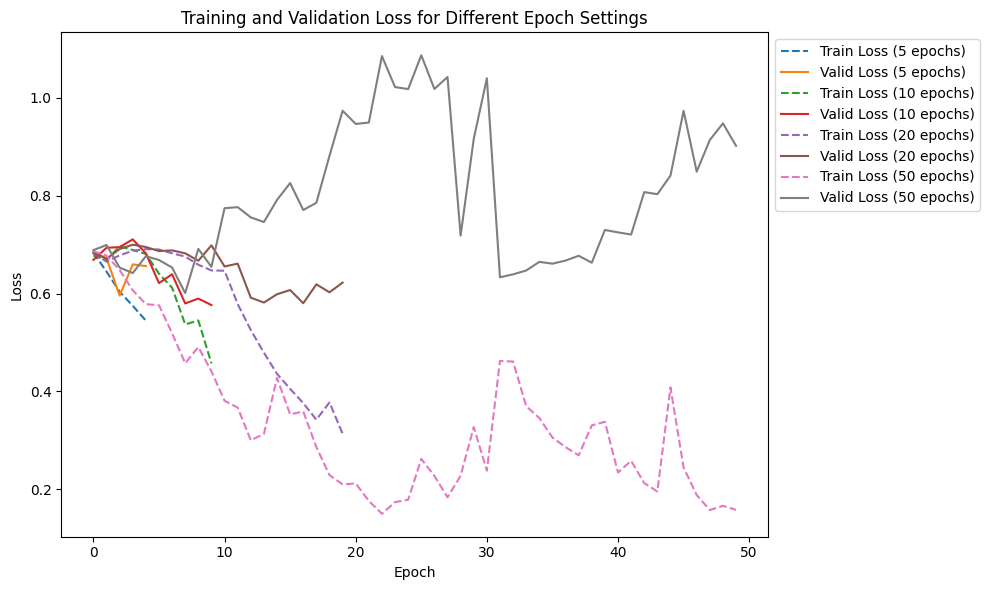

In [88]:
import matplotlib.pyplot as plt
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Plot training and validation loss for different epoch settings
plt.figure(figsize=(10, 6))

for n_epochs in epoch_results:
    plt.plot(epoch_results[n_epochs]["train_loss"], linestyle='--', label=f"Train Loss ({n_epochs} epochs)")
    plt.plot(epoch_results[n_epochs]["valid_loss"], linestyle='-', label=f"Valid Loss ({n_epochs} epochs)")

plt.title("Training and Validation Loss for Different Epoch Settings")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the graph
plt.tight_layout()  # Adjust layout to fit everything

# Save to Google Drive
drive_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/"
os.makedirs(drive_path, exist_ok=True)
file_name_drive = os.path.join(drive_path, "NLPA1_16JAN2025_2A_Loss.png")
plt.savefig(file_name_drive, format="png")
print(f"INFO: Image saved to Google Drive at {file_name_drive}")

# Save locally
file_name_local = "NLPA1_16JAN2025_2A_Loss.png"
plt.savefig(file_name_local, format="png")
print(f"INFO: Image saved locally as {file_name_local}")

# Download the local file
files.download(file_name_local)

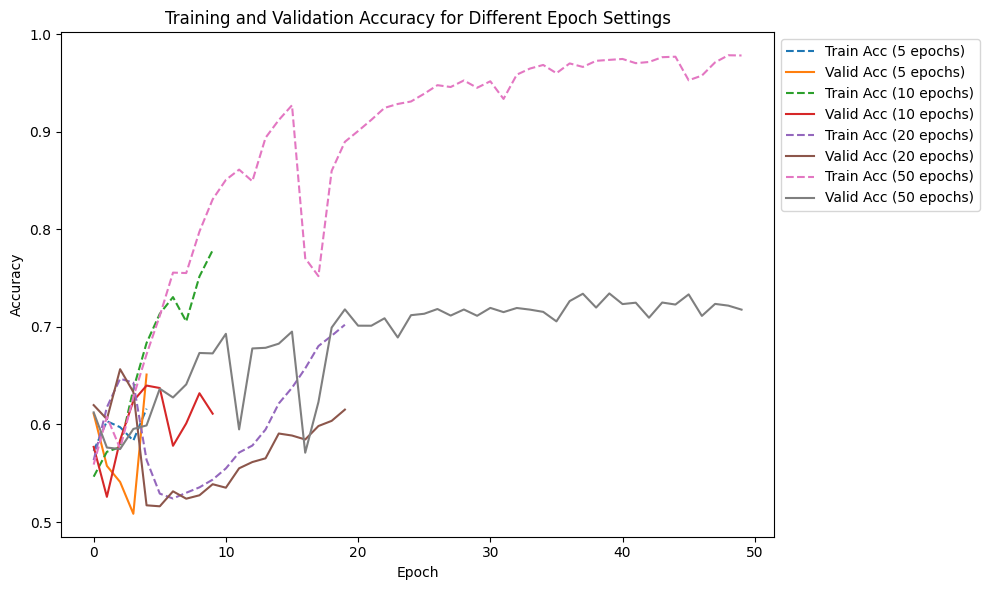

In [ ]:
# plt.figure(figsize=(10, 6))

# for n_epochs in epoch_results:
#     plt.plot(epoch_results[n_epochs]["train_acc"], linestyle='--', label=f"Train Acc ({n_epochs} epochs)")
#     plt.plot(epoch_results[n_epochs]["valid_acc"], linestyle='-', label=f"Valid Acc ({n_epochs} epochs)")

# plt.title("Training and Validation Accuracy for Different Epoch Settings")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the graph
# plt.tight_layout()
# plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Image saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_2B_Accuracy.png
INFO: Image saved locally as NLPA1_16JAN2025_2B_Accuracy.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

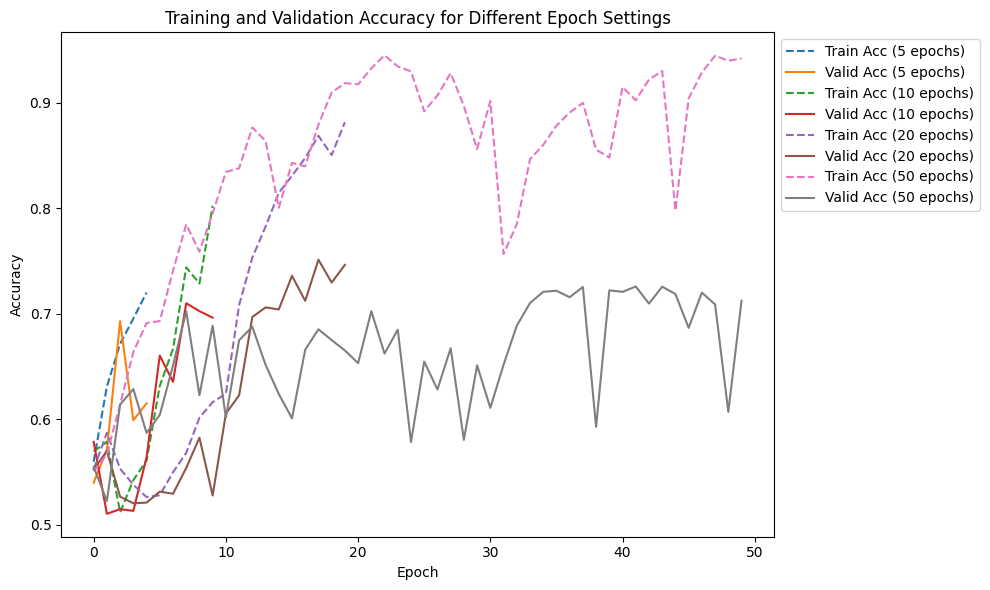

In [89]:
import matplotlib.pyplot as plt
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Plot training and validation accuracy for different epoch settings
plt.figure(figsize=(10, 6))

for n_epochs in epoch_results:
    plt.plot(epoch_results[n_epochs]["train_acc"], linestyle='--', label=f"Train Acc ({n_epochs} epochs)")
    plt.plot(epoch_results[n_epochs]["valid_acc"], linestyle='-', label=f"Valid Acc ({n_epochs} epochs)")

plt.title("Training and Validation Accuracy for Different Epoch Settings")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the graph
plt.tight_layout()  # Adjust layout to fit everything

# Save to Google Drive
drive_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/"
os.makedirs(drive_path, exist_ok=True)
file_name_drive = os.path.join(drive_path, "NLPA1_16JAN2025_2B_Accuracy.png")
plt.savefig(file_name_drive, format="png")
print(f"INFO: Image saved to Google Drive at {file_name_drive}")

# Save locally
file_name_local = "NLPA1_16JAN2025_2B_Accuracy.png"
plt.savefig(file_name_local, format="png")
print(f"INFO: Image saved locally as {file_name_local}")

# Download the local file
files.download(file_name_local)

## 📣TABULATE AND PLOT TEST RESULT BELOW:

In [90]:
# Print test results
for n_epochs, metrics in epoch_results.items():
    print(f"{n_epochs} Epochs | Test Loss: {metrics['test_loss']:.3f} | Test Accuracy: {metrics['test_acc']*100:.2f}%")

5 Epochs | Test Loss: 0.605 | Test Accuracy: 68.45%
10 Epochs | Test Loss: 0.583 | Test Accuracy: 68.93%
20 Epochs | Test Loss: 0.593 | Test Accuracy: 70.71%
50 Epochs | Test Loss: 0.612 | Test Accuracy: 70.41%


In [91]:
import pandas as pd

test_summary = {
    "Epochs": [],
    "Test Loss": [],
    "Test Accuracy (%)": []
}

for n_epochs, metrics in epoch_results.items():
    test_summary["Epochs"].append(n_epochs)
    test_summary["Test Loss"].append(metrics["test_loss"])
    test_summary["Test Accuracy (%)"].append(metrics["test_acc"] * 100)

df = pd.DataFrame(test_summary)
print(df)

   Epochs  Test Loss  Test Accuracy (%)
0       5   0.604624          68.451087
1      10   0.582560          68.931426
2      20   0.592862          70.708120
3      50   0.611790          70.405211


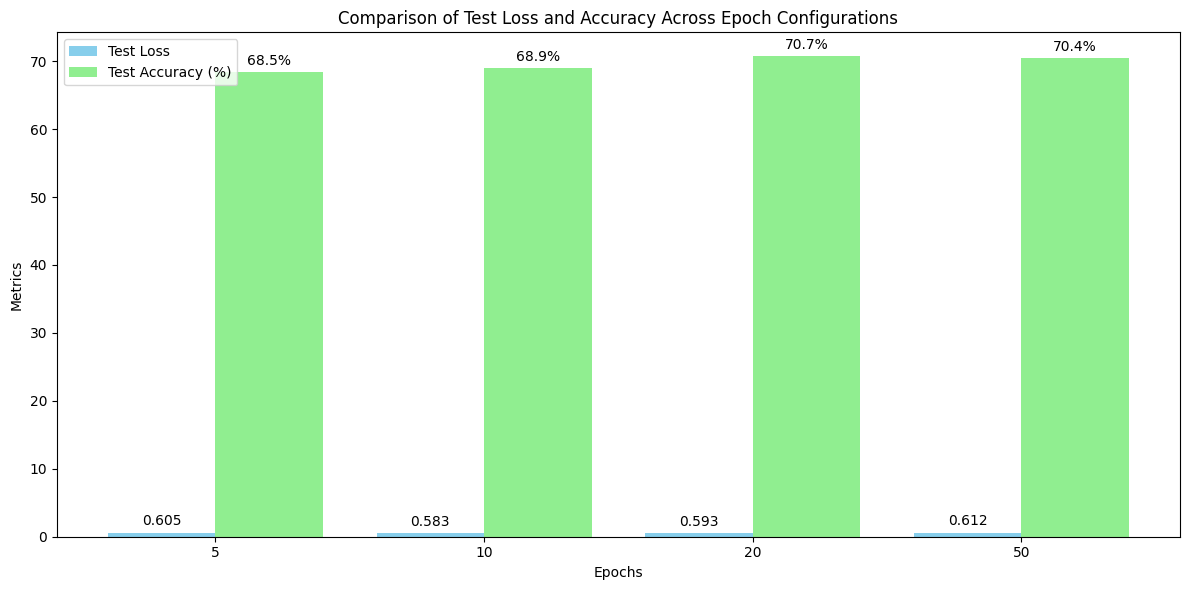

In [92]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Extract data from the DataFrame
# epochs = df["Epochs"].tolist()  # Convert Epochs to list for consistent indexing
# test_losses = df["Test Loss"].tolist()
# test_accuracies = df["Test Accuracy (%)"].tolist()

# # Set bar positions and width
# x = np.arange(len(epochs))  # x positions for bars
# width = 0.4  # Width of bars

# # Create the plot
# fig, ax = plt.subplots(figsize=(12, 6))

# # Plot Test Loss as bars
# loss_bars = ax.bar(x - width / 2, test_losses, width, label="Test Loss", color="skyblue")

# # Plot Test Accuracy as bars
# accuracy_bars = ax.bar(x + width / 2, test_accuracies, width, label="Test Accuracy (%)", color="lightgreen")

# # Add labels, title, and legend
# ax.set_xlabel("Epochs")
# ax.set_ylabel("Metrics")
# ax.set_title("Comparison of Test Loss and Accuracy Across Epoch Configurations")
# ax.set_xticks(x)
# ax.set_xticklabels(epochs)  # Use epoch values as x-axis labels
# ax.legend()

# # Annotate bars with values
# for bar in loss_bars:
#     ax.annotate(f'{bar.get_height():.3f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
#                 xytext=(0, 3),  # Offset for text
#                 textcoords="offset points",
#                 ha="center", va="bottom")

# for bar in accuracy_bars:
#     ax.annotate(f'{bar.get_height():.1f}%',
#                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
#                 xytext=(0, 3),
#                 textcoords="offset points",
#                 ha="center", va="bottom")

# # Adjust layout and display plot
# plt.tight_layout()
# plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Image saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_2C_Comparison.png
INFO: Image saved locally as NLPA1_16JAN2025_2C_Comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

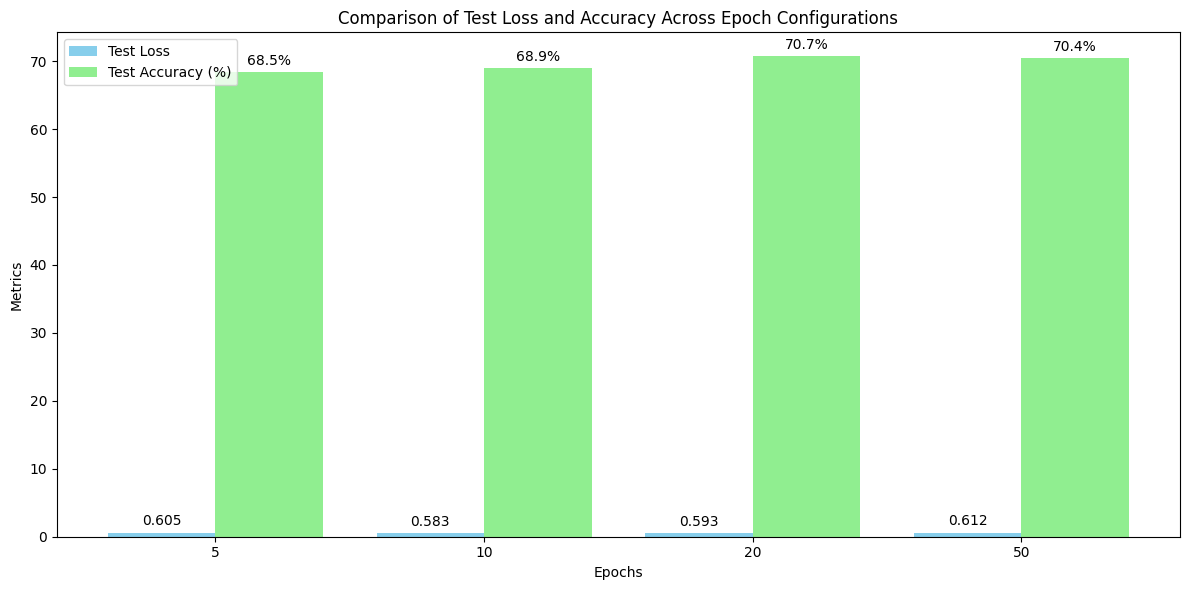

In [93]:
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Extract data from the DataFrame
epochs = df["Epochs"].tolist()  # Convert Epochs to list for consistent indexing
test_losses = df["Test Loss"].tolist()
test_accuracies = df["Test Accuracy (%)"].tolist()

# Set bar positions and width
x = np.arange(len(epochs))  # x positions for bars
width = 0.4  # Width of bars

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Test Loss as bars
loss_bars = ax.bar(x - width / 2, test_losses, width, label="Test Loss", color="skyblue")

# Plot Test Accuracy as bars
accuracy_bars = ax.bar(x + width / 2, test_accuracies, width, label="Test Accuracy (%)", color="lightgreen")

# Add labels, title, and legend
ax.set_xlabel("Epochs")
ax.set_ylabel("Metrics")
ax.set_title("Comparison of Test Loss and Accuracy Across Epoch Configurations")
ax.set_xticks(x)
ax.set_xticklabels(epochs)  # Use epoch values as x-axis labels
ax.legend()

# Annotate bars with values
for bar in loss_bars:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),  # Offset for text
                textcoords="offset points",
                ha="center", va="bottom")

for bar in accuracy_bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom")

# Adjust layout
plt.tight_layout()

# Save to Google Drive
drive_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/"
os.makedirs(drive_path, exist_ok=True)
file_name_drive = os.path.join(drive_path, "NLPA1_16JAN2025_2C_Comparison.png")
plt.savefig(file_name_drive, format="png")
print(f"INFO: Image saved to Google Drive at {file_name_drive}")

# Save locally
file_name_local = "NLPA1_16JAN2025_2C_Comparison.png"
plt.savefig(file_name_local, format="png")
print(f"INFO: Image saved locally as {file_name_local}")

# Download the local file
files.download(file_name_local)

# 🏁STEP 4: VARYING THE MODEL

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F

# # Define Binary Accuracy Function
# def binary_accuracy(preds, y):
#     rounded_preds = torch.round(torch.sigmoid(preds))  # Convert logits to binary predictions
#     correct = (rounded_preds == y).float()  # Convert to float for division
#     return correct.sum() / len(correct)


# # Define Models
# class OneLayerFFNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.fc = nn.Linear(embed_dim, hidden_dim)
#         self.out = nn.Linear(hidden_dim, output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text).mean(dim=1)  # Mean pooling
#         x = torch.relu(self.fc(embedded))
#         return self.out(x).squeeze(1)  # [batch_size]


# class TwoLayerFFNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dims, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.fc1 = nn.Linear(embed_dim, hidden_dims[0])
#         self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
#         self.out = nn.Linear(hidden_dims[1], output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text).mean(dim=1)
#         x = torch.relu(self.fc1(embedded))
#         x = torch.relu(self.fc2(x))
#         return self.out(x).squeeze(1)


# class ThreeLayerFFNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dims, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.fc1 = nn.Linear(embed_dim, hidden_dims[0])
#         self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
#         self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
#         self.out = nn.Linear(hidden_dims[2], output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text).mean(dim=1)
#         x = torch.relu(self.fc1(embedded))
#         x = torch.relu(self.fc2(x))
#         x = torch.relu(self.fc3(x))
#         return self.out(x).squeeze(1)


# class CNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, output_dim, kernel_sizes):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.convs = nn.ModuleList(
#             [nn.Conv2d(1, 100, (k, embed_dim)) for k in kernel_sizes]
#         )
#         self.fc = nn.Linear(len(kernel_sizes) * 100, output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text).unsqueeze(1)
#         conved = [torch.relu(conv(embedded)).squeeze(3) for conv in self.convs]
#         pooled = [torch.max(c, dim=2)[0] for c in conved]
#         cat = torch.cat(pooled, dim=1)
#         return self.fc(cat).squeeze(1)


# class LSTM(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
#         self.fc = nn.Linear(hidden_dim, output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text)
#         _, (hidden, _) = self.lstm(embedded)
#         return self.fc(hidden.squeeze(0)).squeeze(1)


# class BiLSTM(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
#         self.fc = nn.Linear(hidden_dim * 2, output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text)
#         _, (hidden, _) = self.lstm(embedded)
#         hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
#         return self.fc(hidden).squeeze(1)


# # Training Function
# def train_model(model, train_iterator, valid_iterator, optimizer, criterion, n_epochs=10):
#     best_valid_loss = float("inf")

#     for epoch in range(n_epochs):
#         model.train()
#         train_loss, train_acc = 0, 0

#         for batch in train_iterator:
#             optimizer.zero_grad()

#             # Prepare inputs and targets
#             text, text_lengths = batch.text
#             labels = batch.label

#             # Align batch sizes if necessary
#             if text.shape[0] != labels.shape[0]:
#                 min_size = min(text.shape[0], labels.shape[0])
#                 text = text[:min_size]
#                 labels = labels[:min_size]

#             text = text.to(device).long()  # Convert to correct type
#             labels = labels.to(device).float()  # Ensure labels are float for BCEWithLogitsLoss

#             # Forward pass
#             predictions = model(text)  # [batch_size]
#             loss = criterion(predictions, labels)
#             acc = binary_accuracy(predictions, labels)

#             # Backward pass
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()
#             train_acc += acc.item()

#         train_loss /= len(train_iterator)
#         train_acc /= len(train_iterator)

#         # Validation Phase
#         model.eval()
#         valid_loss, valid_acc = 0, 0
#         with torch.no_grad():
#             for batch in valid_iterator:
#                 text, text_lengths = batch.text
#                 labels = batch.label

#                 # Align batch sizes if necessary
#                 if text.shape[0] != labels.shape[0]:
#                     min_size = min(text.shape[0], labels.shape[0])
#                     text = text[:min_size]
#                     labels = labels[:min_size]

#                 text = text.to(device).long()
#                 labels = labels.to(device).float()

#                 predictions = model(text)
#                 loss = criterion(predictions, labels)
#                 acc = binary_accuracy(predictions, labels)

#                 valid_loss += loss.item()
#                 valid_acc += acc.item()

#         valid_loss /= len(valid_iterator)
#         valid_acc /= len(valid_iterator)

#         # Save the best model
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             torch.save(model.state_dict(), f"best_{model.__class__.__name__}.pt")

#     return {
#         "train_loss": train_loss,
#         "valid_loss": valid_loss,
#         "train_acc": train_acc,
#         "valid_acc": valid_acc,
#     }


# # Model Initialization and Training Loop
# INPUT_DIM = 25002
# OUTPUT_DIM = 1
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# models = {
#     "OneLayerFFNN": OneLayerFFNN(INPUT_DIM, 100, 64, OUTPUT_DIM),
#     "TwoLayerFFNN": TwoLayerFFNN(INPUT_DIM, 100, [64, 32], OUTPUT_DIM),
#     "ThreeLayerFFNN": ThreeLayerFFNN(INPUT_DIM, 100, [128, 64, 32], OUTPUT_DIM),
#     "CNN": CNN(INPUT_DIM, 100, OUTPUT_DIM, [1, 2, 3]),
#     "LSTM": LSTM(INPUT_DIM, 100, 256, OUTPUT_DIM),
#     "BiLSTM": BiLSTM(INPUT_DIM, 100, 256, OUTPUT_DIM),
# }

# model_results = {}

# for name, model in models.items():
#     print(f"Training {name}...")
#     model.to(device)
#     optimizer = optim.Adam(model.parameters())
#     criterion = nn.BCEWithLogitsLoss()
#     results = train_model(model, train_iterator, valid_iterator, optimizer, criterion)
#     model_results[name] = results
#     print(f"Finished training {name}.\n")

## THE ONE WITH TEST LOSS AND TEST ACCURACY

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F

# # Define Binary Accuracy Function
# def binary_accuracy(preds, y):
#     rounded_preds = torch.round(torch.sigmoid(preds))  # Convert logits to binary predictions
#     correct = (rounded_preds == y).float()  # Convert to float for division
#     return correct.sum() / len(correct)


# # Define Models
# class OneLayerFFNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.fc = nn.Linear(embed_dim, hidden_dim)
#         self.out = nn.Linear(hidden_dim, output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text).mean(dim=1)  # Mean pooling
#         x = torch.relu(self.fc(embedded))
#         return self.out(x).squeeze(1)  # [batch_size]


# class TwoLayerFFNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dims, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.fc1 = nn.Linear(embed_dim, hidden_dims[0])
#         self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
#         self.out = nn.Linear(hidden_dims[1], output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text).mean(dim=1)
#         x = torch.relu(self.fc1(embedded))
#         x = torch.relu(self.fc2(x))
#         return self.out(x).squeeze(1)


# class ThreeLayerFFNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dims, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.fc1 = nn.Linear(embed_dim, hidden_dims[0])
#         self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
#         self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
#         self.out = nn.Linear(hidden_dims[2], output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text).mean(dim=1)
#         x = torch.relu(self.fc1(embedded))
#         x = torch.relu(self.fc2(x))
#         x = torch.relu(self.fc3(x))
#         return self.out(x).squeeze(1)


# class CNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, output_dim, kernel_sizes):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.convs = nn.ModuleList(
#             [nn.Conv2d(1, 100, (k, embed_dim)) for k in kernel_sizes]
#         )
#         self.fc = nn.Linear(len(kernel_sizes) * 100, output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text).unsqueeze(1)
#         conved = [torch.relu(conv(embedded)).squeeze(3) for conv in self.convs]
#         pooled = [torch.max(c, dim=2)[0] for c in conved]
#         cat = torch.cat(pooled, dim=1)
#         return self.fc(cat).squeeze(1)


# class LSTM(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
#         self.fc = nn.Linear(hidden_dim, output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text)
#         _, (hidden, _) = self.lstm(embedded)
#         return self.fc(hidden.squeeze(0)).squeeze(1)


# class BiLSTM(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim)
#         self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
#         self.fc = nn.Linear(hidden_dim * 2, output_dim)

#     def forward(self, text):
#         embedded = self.embedding(text)
#         _, (hidden, _) = self.lstm(embedded)
#         hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
#         return self.fc(hidden).squeeze(1)


# # Training Function
# def train_model(model, train_iterator, valid_iterator, test_iterator, optimizer, criterion, n_epochs=10):
#     best_valid_loss = float("inf")
#     best_model_path = f"best_{model.__class__.__name__}.pt"  # Path to save the best model

#     for epoch in range(n_epochs):
#         model.train()
#         train_loss, train_acc = 0, 0

#         for batch in train_iterator:
#             optimizer.zero_grad()

#             # Prepare inputs and targets
#             text, text_lengths = batch.text
#             labels = batch.label

#             # Align batch sizes if necessary
#             if text.shape[0] != labels.shape[0]:
#                 min_size = min(text.shape[0], labels.shape[0])
#                 text = text[:min_size]
#                 labels = labels[:min_size]

#             text = text.to(device).long()  # Convert to correct type
#             labels = labels.to(device).float()  # Ensure labels are float for BCEWithLogitsLoss

#             # Forward pass
#             predictions = model(text)  # [batch_size]
#             loss = criterion(predictions, labels)
#             acc = binary_accuracy(predictions, labels)

#             # Backward pass
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()
#             train_acc += acc.item()

#         train_loss /= len(train_iterator)
#         train_acc /= len(train_iterator)

#         # Validation Phase
#         model.eval()
#         valid_loss, valid_acc = 0, 0
#         with torch.no_grad():
#             for batch in valid_iterator:
#                 text, text_lengths = batch.text
#                 labels = batch.label

#                 # Align batch sizes if necessary
#                 if text.shape[0] != labels.shape[0]:
#                     min_size = min(text.shape[0], labels.shape[0])
#                     text = text[:min_size]
#                     labels = labels[:min_size]

#                 text = text.to(device).long()
#                 labels = labels.to(device).float()

#                 predictions = model(text)
#                 loss = criterion(predictions, labels)
#                 acc = binary_accuracy(predictions, labels)

#                 valid_loss += loss.item()
#                 valid_acc += acc.item()

#         valid_loss /= len(valid_iterator)
#         valid_acc /= len(valid_iterator)

#         # Save the best model
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             torch.save(model.state_dict(), best_model_path)

#     # Load the best model and evaluate on the test set
#     model.load_state_dict(torch.load(best_model_path))
#     test_loss, test_acc = evaluate_test_set(model, test_iterator, criterion)

#     return {
#         "train_loss": train_loss,
#         "valid_loss": valid_loss,
#         "train_acc": train_acc,
#         "valid_acc": valid_acc,
#         "test_loss": test_loss,
#         "test_acc": test_acc,
#     }


# def evaluate_test_set(model, test_iterator, criterion):
#     model.eval()
#     test_loss, test_acc = 0, 0
#     with torch.no_grad():
#         for batch in test_iterator:
#             text, text_lengths = batch.text
#             labels = batch.label

#             # Align batch sizes if necessary
#             if text.shape[0] != labels.shape[0]:
#                 min_size = min(text.shape[0], labels.shape[0])
#                 text = text[:min_size]
#                 labels = labels[:min_size]

#             text = text.to(device).long()
#             labels = labels.to(device).float()

#             predictions = model(text)
#             loss = criterion(predictions, labels)
#             acc = binary_accuracy(predictions, labels)

#             test_loss += loss.item()
#             test_acc += acc.item()

#     test_loss /= len(test_iterator)
#     test_acc /= len(test_iterator)

#     return test_loss, test_acc


# # Model Initialization and Training Loop
# INPUT_DIM = 25002
# OUTPUT_DIM = 1
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# models = {
#     "OneLayerFFNN": OneLayerFFNN(INPUT_DIM, 100, 64, OUTPUT_DIM),
#     "TwoLayerFFNN": TwoLayerFFNN(INPUT_DIM, 100, [64, 32], OUTPUT_DIM),
#     "ThreeLayerFFNN": ThreeLayerFFNN(INPUT_DIM, 100, [128, 64, 32], OUTPUT_DIM),
#     "CNN": CNN(INPUT_DIM, 100, OUTPUT_DIM, [1, 2, 3]),
#     "LSTM": LSTM(INPUT_DIM, 100, 256, OUTPUT_DIM),
#     "BiLSTM": BiLSTM(INPUT_DIM, 100, 256, OUTPUT_DIM),
# }

# model_results = {}

# for name, model in models.items():
#     print(f"Training {name}...")
#     model.to(device)
#     optimizer = optim.Adam(model.parameters())
#     criterion = nn.BCEWithLogitsLoss()
#     results = train_model(model, train_iterator, valid_iterator, test_iterator, optimizer, criterion)
#     model_results[name] = results
#     print(f"Finished training {name}.\n")

## THE ONE WITH EPOCH WISE LINE PLOTS

In [115]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Define Binary Accuracy Function
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))  # Convert logits to binary predictions
    correct = (rounded_preds == y).float()  # Convert to float for division
    return correct.sum() / len(correct)


# Define Models
class OneLayerFFNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text).mean(dim=1)  # Mean pooling
        x = torch.relu(self.fc(embedded))
        return self.out(x).squeeze(1)  # [batch_size]


class TwoLayerFFNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dims, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc1 = nn.Linear(embed_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.out = nn.Linear(hidden_dims[1], output_dim)

    def forward(self, text):
        embedded = self.embedding(text).mean(dim=1)
        x = torch.relu(self.fc1(embedded))
        x = torch.relu(self.fc2(x))
        return self.out(x).squeeze(1)


class ThreeLayerFFNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dims, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc1 = nn.Linear(embed_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.out = nn.Linear(hidden_dims[2], output_dim)

    def forward(self, text):
        embedded = self.embedding(text).mean(dim=1)
        x = torch.relu(self.fc1(embedded))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.out(x).squeeze(1)


class CNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, output_dim, kernel_sizes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.convs = nn.ModuleList(
            [nn.Conv2d(1, 100, (k, embed_dim)) for k in kernel_sizes]
        )
        self.fc = nn.Linear(len(kernel_sizes) * 100, output_dim)

    def forward(self, text):
        embedded = self.embedding(text).unsqueeze(1)
        conved = [torch.relu(conv(embedded)).squeeze(3) for conv in self.convs]
        pooled = [torch.max(c, dim=2)[0] for c in conved]
        cat = torch.cat(pooled, dim=1)
        return self.fc(cat).squeeze(1)


class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        _, (hidden, _) = self.lstm(embedded)
        return self.fc(hidden.squeeze(0)).squeeze(1)


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        return self.fc(hidden).squeeze(1)


# Training Function
def train_model(model, train_iterator, valid_iterator, test_iterator, optimizer, criterion, n_epochs=10):
    best_valid_loss = float("inf")
    best_model_path = f"best_{model.__class__.__name__}.pt"  # Path to save the best model

    # Track metrics for each epoch
    epoch_train_losses = []
    epoch_valid_losses = []
    epoch_train_accuracies = []
    epoch_valid_accuracies = []

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_acc = 0, 0

        for batch in train_iterator:
            optimizer.zero_grad()

            # Prepare inputs and targets
            text, text_lengths = batch.text
            labels = batch.label

            if text.shape[0] != labels.shape[0]:
                min_size = min(text.shape[0], labels.shape[0])
                text = text[:min_size]
                labels = labels[:min_size]

            text = text.to(device).long()
            labels = labels.to(device).float()

            # Forward pass
            predictions = model(text)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += acc.item()

        train_loss /= len(train_iterator)
        train_acc /= len(train_iterator)
        epoch_train_losses.append(train_loss)  # Record epoch train loss
        epoch_train_accuracies.append(train_acc)  # Record epoch train accuracy

        # Validation Phase
        model.eval()
        valid_loss, valid_acc = 0, 0
        with torch.no_grad():
            for batch in valid_iterator:
                text, text_lengths = batch.text
                labels = batch.label

                if text.shape[0] != labels.shape[0]:
                    min_size = min(text.shape[0], labels.shape[0])
                    text = text[:min_size]
                    labels = labels[:min_size]

                text = text.to(device).long()
                labels = labels.to(device).float()

                predictions = model(text)
                loss = criterion(predictions, labels)
                acc = binary_accuracy(predictions, labels)

                valid_loss += loss.item()
                valid_acc += acc.item()

        valid_loss /= len(valid_iterator)
        valid_acc /= len(valid_iterator)
        epoch_valid_losses.append(valid_loss)  # Record epoch validation loss
        epoch_valid_accuracies.append(valid_acc)  # Record epoch validation accuracy

        # Save the best model
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), best_model_path)

    # Load the best model and evaluate on the test set
    model.load_state_dict(torch.load(best_model_path))
    test_loss, test_acc = evaluate_test_set(model, test_iterator, criterion)

    return {
        "epoch_train_loss": epoch_train_losses,
        "epoch_valid_loss": epoch_valid_losses,
        "epoch_train_acc": epoch_train_accuracies,
        "epoch_valid_acc": epoch_valid_accuracies,
        "test_loss": test_loss,
        "test_acc": test_acc,
    }


def evaluate_test_set(model, test_iterator, criterion):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.no_grad():
        for batch in test_iterator:
            text, text_lengths = batch.text
            labels = batch.label

            # Align batch sizes if necessary
            if text.shape[0] != labels.shape[0]:
                min_size = min(text.shape[0], labels.shape[0])
                text = text[:min_size]
                labels = labels[:min_size]

            text = text.to(device).long()
            labels = labels.to(device).float()

            predictions = model(text)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            test_loss += loss.item()
            test_acc += acc.item()

    test_loss /= len(test_iterator)
    test_acc /= len(test_iterator)

    return test_loss, test_acc


# Model Initialization and Training Loop
INPUT_DIM = 25002
OUTPUT_DIM = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {
    "OneLayerFFNN": OneLayerFFNN(INPUT_DIM, 100, 64, OUTPUT_DIM),
    "TwoLayerFFNN": TwoLayerFFNN(INPUT_DIM, 100, [64, 32], OUTPUT_DIM),
    "ThreeLayerFFNN": ThreeLayerFFNN(INPUT_DIM, 100, [128, 64, 32], OUTPUT_DIM),
    "CNN": CNN(INPUT_DIM, 100, OUTPUT_DIM, [1, 2, 3]),
    "LSTM": LSTM(INPUT_DIM, 100, 256, OUTPUT_DIM),
    "BiLSTM": BiLSTM(INPUT_DIM, 100, 256, OUTPUT_DIM),
}

model_results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.to(device)
    optimizer = optim.Adam(model.parameters())
    criterion = nn.BCEWithLogitsLoss()
    results = train_model(model, train_iterator, valid_iterator, test_iterator, optimizer, criterion)
    model_results[name] = results
    print(f"Finished training {name}.\n")

Training OneLayerFFNN...


<ipython-input-115-80ba0b1abc0c>:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Finished training OneLayerFFNN.

Training TwoLayerFFNN...
Finished training TwoLayerFFNN.

Training ThreeLayerFFNN...
Finished training ThreeLayerFFNN.

Training CNN...
Finished training CNN.

Training LSTM...
Finished training LSTM.

Training BiLSTM...
Finished training BiLSTM.



In [116]:
model_results

{'OneLayerFFNN': {'epoch_train_loss': [0.6937583245500161,
   0.6935884898161366,
   0.6932440280479236,
   0.6933524460688124,
   0.6931341832136586,
   0.6931380157488106,
   0.6929960340043925,
   0.692951117336315,
   0.6933442917618439,
   0.69313759068503],
  'epoch_valid_loss': [0.693605391150814,
   0.6929608159146067,
   0.6929574103678687,
   0.6929080557014983,
   0.6933282391499664,
   0.6929150688446174,
   0.69295468219256,
   0.6934717075299408,
   0.69312676736864,
   0.6930801262289791],
  'epoch_train_acc': [0.5015981977220869,
   0.5022776242155228,
   0.5025883792308126,
   0.5016682643959992,
   0.508476578623709,
   0.506445734605302,
   0.5088116470044547,
   0.5112873069996381,
   0.500833414005537,
   0.502625998136771],
  'epoch_valid_acc': [0.4960544210369304,
   0.5139828708212254,
   0.5026327596377518,
   0.5070060370332103,
   0.5051043654902506,
   0.5062543469465385,
   0.5043160632505255,
   0.4965047548382969,
   0.5085577098494869,
   0.5069505079823

## 📝SAVE RESULT BELOW:

In [117]:
# Define the model_results dictionary
model_results_saved_16JAN2025 = model_results  # Replace with your actual dictionary

# Flatten the `model_results` dictionary
flattened_results = []
for model_name, metrics in model_results_saved_16JAN2025.items():
    for epoch, (train_loss, valid_loss, train_acc, valid_acc) in enumerate(zip(
        metrics.get("epoch_train_loss", []),
        metrics.get("epoch_valid_loss", []),
        metrics.get("epoch_train_acc", []),
        metrics.get("epoch_valid_acc", []),
    ), start=1):
        flattened_results.append({
            "Model": model_name,
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Validation Loss": valid_loss,
            "Train Accuracy": train_acc * 100,  # Convert to percentage
            "Validation Accuracy": valid_acc * 100,  # Convert to percentage
        })
    # Append test results once per model
    flattened_results.append({
        "Model": model_name,
        "Epoch": "Test",  # Use "Test" to indicate test results
        "Train Loss": None,
        "Validation Loss": None,
        "Train Accuracy": None,
        "Validation Accuracy": None,
        "Test Loss": metrics.get("test_loss"),
        "Test Accuracy": metrics.get("test_acc") * 100 if metrics.get("test_acc") else None,  # Convert to percentage
    })

# Convert to DataFrame
df_model_results = pd.DataFrame(flattened_results)

# Save to a local CSV file
model_csv_filename = "model_results_saved_16JAN2025.csv"
df_model_results.to_csv(model_csv_filename, index=False)
print(f"INFO: Model results saved locally to {model_csv_filename}")

# Download the local CSV file
files.download(model_csv_filename)

# Save to Google Drive
drive_path_model = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/model_results_saved_16JAN2025.csv"
df_model_results.to_csv(drive_path_model, index=False)
print(f"INFO: Model results saved to Google Drive at {drive_path_model}")

INFO: Model results saved locally to model_results_saved_16JAN2025.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

INFO: Model results saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/model_results_saved_16JAN2025.csv


In [118]:
model_results_saved_16JAN2025

{'OneLayerFFNN': {'epoch_train_loss': [0.6937583245500161,
   0.6935884898161366,
   0.6932440280479236,
   0.6933524460688124,
   0.6931341832136586,
   0.6931380157488106,
   0.6929960340043925,
   0.692951117336315,
   0.6933442917618439,
   0.69313759068503],
  'epoch_valid_loss': [0.693605391150814,
   0.6929608159146067,
   0.6929574103678687,
   0.6929080557014983,
   0.6933282391499664,
   0.6929150688446174,
   0.69295468219256,
   0.6934717075299408,
   0.69312676736864,
   0.6930801262289791],
  'epoch_train_acc': [0.5015981977220869,
   0.5022776242155228,
   0.5025883792308126,
   0.5016682643959992,
   0.508476578623709,
   0.506445734605302,
   0.5088116470044547,
   0.5112873069996381,
   0.500833414005537,
   0.502625998136771],
  'epoch_valid_acc': [0.4960544210369304,
   0.5139828708212254,
   0.5026327596377518,
   0.5070060370332103,
   0.5051043654902506,
   0.5062543469465385,
   0.5043160632505255,
   0.4965047548382969,
   0.5085577098494869,
   0.5069505079823

## PLOT RESULT BELOW:

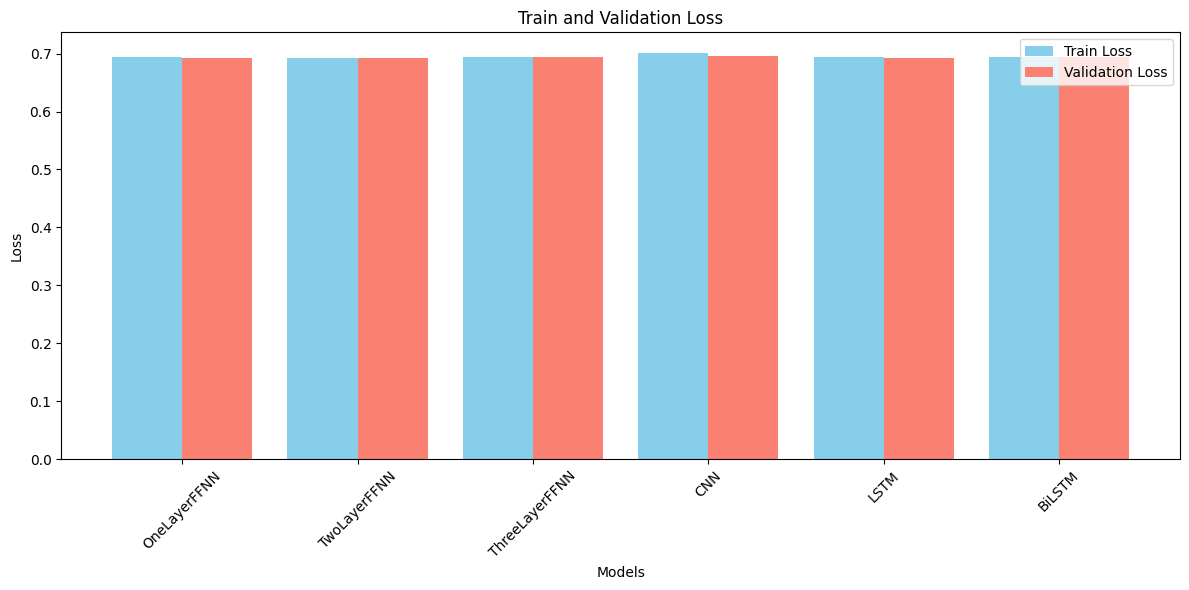

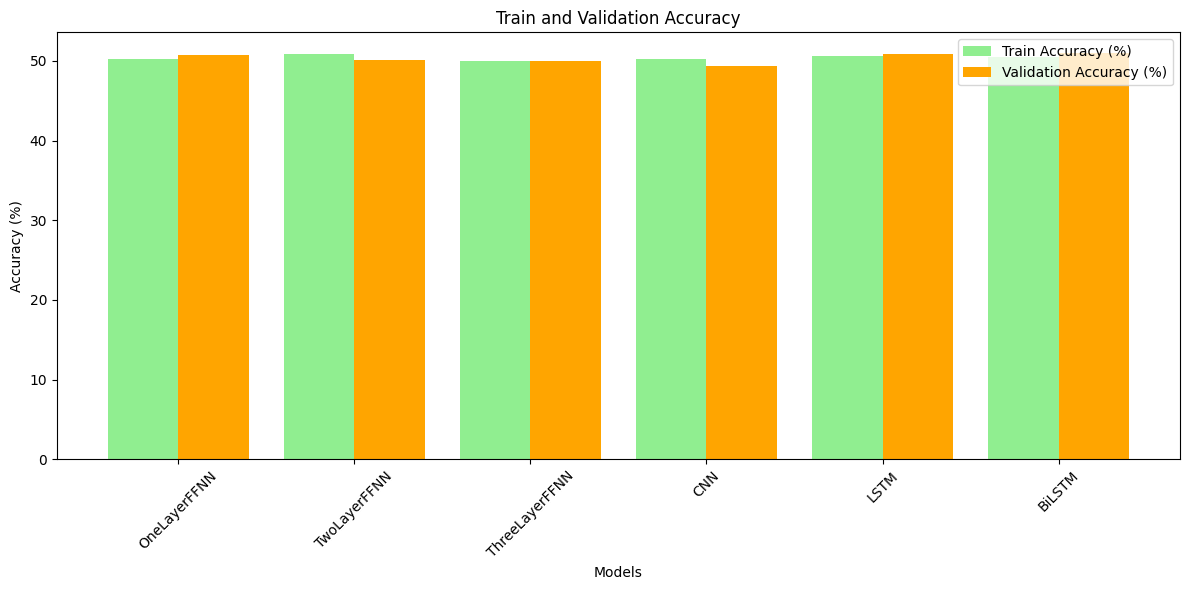

In [ ]:
# # Prepare data for plotting
# models = list(model_results.keys())
# train_losses = [model_results[model]["epoch_train_loss"][-1] for model in models]  # Use the last epoch's train loss
# valid_losses = [model_results[model]["epoch_valid_loss"][-1] for model in models]  # Use the last epoch's valid loss
# train_accuracies = [model_results[model]["epoch_train_acc"][-1] * 100 for model in models]  # Last epoch's train acc
# valid_accuracies = [model_results[model]["epoch_valid_acc"][-1] * 100 for model in models]  # Last epoch's valid acc

# # Plot Losses
# plt.figure(figsize=(12, 6))
# x = np.arange(len(models))  # X positions for bars
# width = 0.4  # Width of bars

# plt.bar(x - width / 2, train_losses, width, label="Train Loss", color="skyblue")
# plt.bar(x + width / 2, valid_losses, width, label="Validation Loss", color="salmon")
# plt.xticks(x, models, rotation=45)
# plt.title("Train and Validation Loss")
# plt.xlabel("Models")
# plt.ylabel("Loss")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # Plot Accuracies
# plt.figure(figsize=(12, 6))
# plt.bar(x - width / 2, train_accuracies, width, label="Train Accuracy (%)", color="lightgreen")
# plt.bar(x + width / 2, valid_accuracies, width, label="Validation Accuracy (%)", color="orange")
# plt.xticks(x, models, rotation=45)
# plt.title("Train and Validation Accuracy")
# plt.xlabel("Models")
# plt.ylabel("Accuracy (%)")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [119]:
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Prepare data for plotting
models = list(model_results.keys())
train_losses = [model_results[model]["epoch_train_loss"][-1] for model in models]  # Last epoch's train loss
valid_losses = [model_results[model]["epoch_valid_loss"][-1] for model in models]  # Last epoch's valid loss
train_accuracies = [model_results[model]["epoch_train_acc"][-1] * 100 for model in models]  # Last epoch's train acc
valid_accuracies = [model_results[model]["epoch_valid_acc"][-1] * 100 for model in models]  # Last epoch's valid acc

# Plot Losses
plt.figure(figsize=(12, 6))
x = np.arange(len(models))  # X positions for bars
width = 0.4  # Width of bars

plt.bar(x - width / 2, train_losses, width, label="Train Loss", color="skyblue")
plt.bar(x + width / 2, valid_losses, width, label="Validation Loss", color="salmon")
plt.xticks(x, models, rotation=45)
plt.title("Train and Validation Loss")
plt.xlabel("Models")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

# Save Loss Plot
drive_path_loss = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3A_Loss.png"
local_file_loss = "NLPA1_16JAN2025_3A_Loss.png"
plt.savefig(drive_path_loss, format="png")
print(f"INFO: Loss plot saved to Google Drive at {drive_path_loss}")
plt.savefig(local_file_loss, format="png")
print(f"INFO: Loss plot saved locally as {local_file_loss}")
files.download(local_file_loss)
plt.close()

# Plot Accuracies
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, train_accuracies, width, label="Train Accuracy (%)", color="lightgreen")
plt.bar(x + width / 2, valid_accuracies, width, label="Validation Accuracy (%)", color="orange")
plt.xticks(x, models, rotation=45)
plt.title("Train and Validation Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()

# Save Accuracy Plot
drive_path_acc = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3B_Acc.png"
local_file_acc = "NLPA1_16JAN2025_3B_Acc.png"
plt.savefig(drive_path_acc, format="png")
print(f"INFO: Accuracy plot saved to Google Drive at {drive_path_acc}")
plt.savefig(local_file_acc, format="png")
print(f"INFO: Accuracy plot saved locally as {local_file_acc}")
files.download(local_file_acc)
plt.close()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Loss plot saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3A_Loss.png
INFO: Loss plot saved locally as NLPA1_16JAN2025_3A_Loss.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

INFO: Accuracy plot saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3B_Acc.png
INFO: Accuracy plot saved locally as NLPA1_16JAN2025_3B_Acc.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

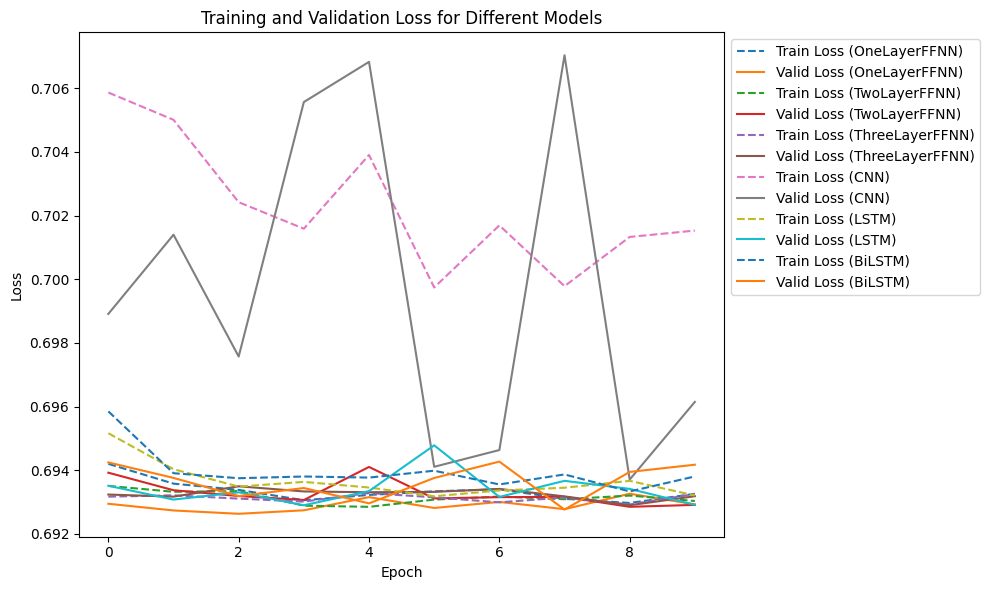

In [ ]:
# plt.figure(figsize=(10, 6))

# for model_name, metrics in model_results.items():
#     plt.plot(metrics["epoch_train_loss"], linestyle='--', label=f"Train Loss ({model_name})")
#     plt.plot(metrics["epoch_valid_loss"], linestyle='-', label=f"Valid Loss ({model_name})")

# plt.title("Training and Validation Loss for Different Models")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the graph
# plt.tight_layout()
# plt.show()

In [120]:
import matplotlib.pyplot as plt
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Plot Loss for Different Models
plt.figure(figsize=(10, 6))

for model_name, metrics in model_results.items():
    plt.plot(metrics["epoch_train_loss"], linestyle='--', label=f"Train Loss ({model_name})")
    plt.plot(metrics["epoch_valid_loss"], linestyle='-', label=f"Valid Loss ({model_name})")

plt.title("Training and Validation Loss for Different Models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the graph
plt.tight_layout()

# Save Loss Plot
drive_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3C_Loss.png"
local_file = "NLPA1_16JAN2025_3C_Loss.png"
plt.savefig(drive_path, format="png")
print(f"INFO: Plot saved to Google Drive at {drive_path}")
plt.savefig(local_file, format="png")
print(f"INFO: Plot saved locally as {local_file}")
files.download(local_file)
plt.close()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Plot saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3C_Loss.png
INFO: Plot saved locally as NLPA1_16JAN2025_3C_Loss.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

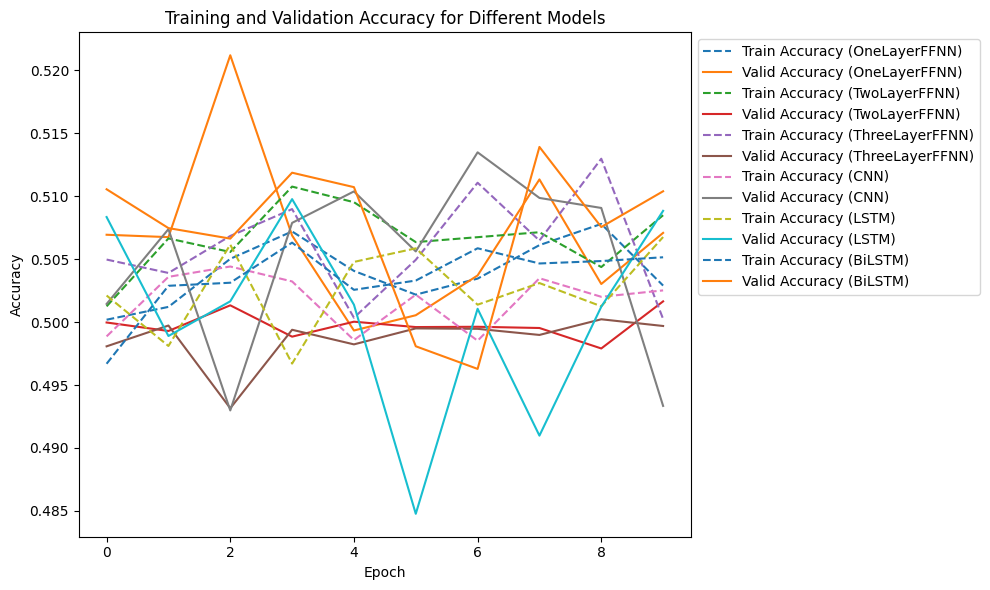

In [ ]:
# plt.figure(figsize=(10, 6))

# for model_name, metrics in model_results.items():
#     plt.plot(metrics["epoch_train_acc"], linestyle='--', label=f"Train Accuracy ({model_name})")
#     plt.plot(metrics["epoch_valid_acc"], linestyle='-', label=f"Valid Accuracy ({model_name})")

# plt.title("Training and Validation Accuracy for Different Models")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the graph
# plt.tight_layout()
# plt.show()

In [121]:
import matplotlib.pyplot as plt
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Plot Accuracy for Different Models
plt.figure(figsize=(10, 6))

for model_name, metrics in model_results.items():
    plt.plot(metrics["epoch_train_acc"], linestyle='--', label=f"Train Accuracy ({model_name})")
    plt.plot(metrics["epoch_valid_acc"], linestyle='-', label=f"Valid Accuracy ({model_name})")

plt.title("Training and Validation Accuracy for Different Models")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Place legend outside the graph
plt.tight_layout()

# Save Accuracy Plot
drive_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3D_Accuracy.png"
local_file = "NLPA1_16JAN2025_3D_Accuracy.png"
plt.savefig(drive_path, format="png")
print(f"INFO: Plot saved to Google Drive at {drive_path}")
plt.savefig(local_file, format="png")
print(f"INFO: Plot saved locally as {local_file}")
files.download(local_file)
plt.close()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Plot saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3D_Accuracy.png
INFO: Plot saved locally as NLPA1_16JAN2025_3D_Accuracy.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

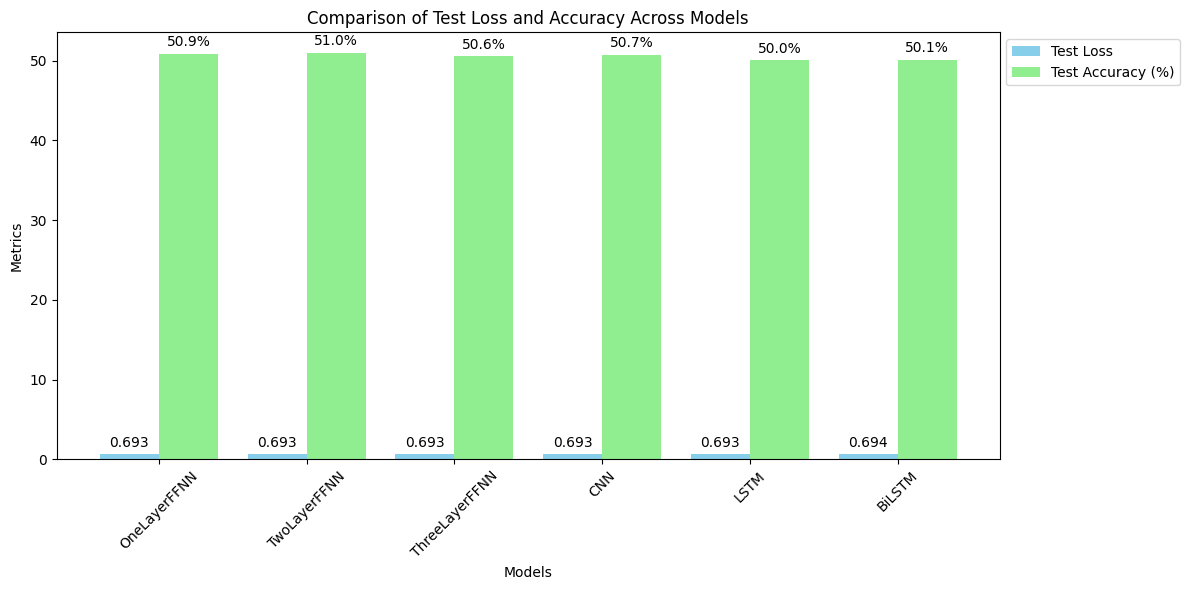

In [ ]:
# import numpy as np

# # Extract data from model_results
# model_names = list(model_results.keys())
# test_losses = [model_results[model]["test_loss"] for model in model_names]
# test_accuracies = [model_results[model]["test_acc"] * 100 for model in model_names]  # Convert to percentage

# # Set bar positions and width
# x = np.arange(len(model_names))  # x positions for bars
# width = 0.4  # Width of bars

# # Create the plot
# fig, ax = plt.subplots(figsize=(12, 6))

# # Plot Test Loss as bars
# loss_bars = ax.bar(x - width / 2, test_losses, width, label="Test Loss", color="skyblue")

# # Plot Test Accuracy as bars
# accuracy_bars = ax.bar(x + width / 2, test_accuracies, width, label="Test Accuracy (%)", color="lightgreen")

# # Add labels, title, and legend
# ax.set_xlabel("Models")
# ax.set_ylabel("Metrics")
# ax.set_title("Comparison of Test Loss and Accuracy Across Models")
# ax.set_xticks(x)
# ax.set_xticklabels(model_names, rotation=45)  # Use model names as x-axis labels
# ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside the plot

# # Annotate bars with values
# for bar in loss_bars:
#     ax.annotate(f'{bar.get_height():.3f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
#                 xytext=(0, 3),  # Offset for text
#                 textcoords="offset points",
#                 ha="center", va="bottom")

# for bar in accuracy_bars:
#     ax.annotate(f'{bar.get_height():.1f}%',
#                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
#                 xytext=(0, 3),
#                 textcoords="offset points",
#                 ha="center", va="bottom")

# # Adjust layout and display plot
# plt.tight_layout()
# plt.show()

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import os
from google.colab import drive
from google.colab import files

# Mount Google Drive
drive.mount('/content/drive')

# Extract data from model_results
model_names = list(model_results.keys())
test_losses = [model_results[model]["test_loss"] for model in model_names]
test_accuracies = [model_results[model]["test_acc"] * 100 for model in model_names]  # Convert to percentage

# Set bar positions and width
x = np.arange(len(model_names))  # x positions for bars
width = 0.4  # Width of bars

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Test Loss as bars
loss_bars = ax.bar(x - width / 2, test_losses, width, label="Test Loss", color="skyblue")

# Plot Test Accuracy as bars
accuracy_bars = ax.bar(x + width / 2, test_accuracies, width, label="Test Accuracy (%)", color="lightgreen")

# Add labels, title, and legend
ax.set_xlabel("Models")
ax.set_ylabel("Metrics")
ax.set_title("Comparison of Test Loss and Accuracy Across Models")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)  # Use model names as x-axis labels
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside the plot

# Annotate bars with values
for bar in loss_bars:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),  # Offset for text
                textcoords="offset points",
                ha="center", va="bottom")

for bar in accuracy_bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom")

# Adjust layout and save the plot
plt.tight_layout()

# Save Comparison Plot
drive_path = "/content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3E_Comparison.png"
local_file = "NLPA1_16JAN2025_3E_Comparison.png"
plt.savefig(drive_path, format="png")
print(f"INFO: Plot saved to Google Drive at {drive_path}")
plt.savefig(local_file, format="png")
print(f"INFO: Plot saved locally as {local_file}")
files.download(local_file)
plt.close()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFO: Plot saved to Google Drive at /content/drive/MyDrive/2025/NTU/MH6812: Advanced NLP/NLPA1_16JAN2025_3E_Comparison.png
INFO: Plot saved locally as NLPA1_16JAN2025_3E_Comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next Steps

In the next notebook, the improvements we will make are:
- packed padded sequences
- pre-trained word embeddings
- different RNN architecture
- bidirectional RNN
- multi-layer RNN
- regularization
- a different optimizer

This will allow us to achieve ~84% accuracy.

### **Understanding Train, Validation, and Test Metrics**

#### **1. Train Loss**
- **Definition**:  
  The loss calculated on the training dataset during each epoch.  
  It measures how well the model is performing on the **data it is being trained on**.  

- **Interpretation**:  
  - A high train loss means the model is struggling to fit the training data.  
  - A very low train loss might indicate **overfitting** (the model is too tuned to the training data).  

---

#### **2. Train Accuracy**
- **Definition**:  
  The percentage of correct predictions made by the model on the training dataset during each epoch.  
  It shows how well the model has **learned patterns in the training data**.  

- **Interpretation**:  
  - High train accuracy combined with low valid/test accuracy may indicate **overfitting**.  
  - Low train accuracy suggests **underfitting** or that the model is not powerful enough.  

---

#### **3. Validation Loss**
- **Definition**:  
  The loss calculated on the validation dataset after each epoch.  
  Validation data is separate from the training data and is not used to update model weights.  
  It measures the model’s ability to **generalize to unseen data**.  

- **Interpretation**:  
  - A lower validation loss indicates better generalization.  
  - If validation loss decreases alongside train loss, it suggests the model is learning well.  
  - If validation loss increases while train loss decreases, it suggests **overfitting**.  

---

#### **4. Validation Accuracy**
- **Definition**:  
  The percentage of correct predictions made by the model on the validation dataset.  
  It shows how well the model **generalizes to unseen data**.  

- **Interpretation**:  
  - High validation accuracy indicates good generalization.  
  - A large gap between train and validation accuracy might indicate **overfitting**.  

---

#### **5. Test Loss**
- **Definition**:  
  The loss calculated on the test dataset **after training is complete**.  
  The test data is entirely separate from both the training and validation datasets.  
  It provides a final evaluation of how well the model is expected to perform in real-world scenarios.  

- **Interpretation**:  
  - Lower test loss indicates the model performs well on unseen data.  
  - High test loss compared to validation loss might indicate **overfitting** or a **distribution mismatch** between validation and test datasets.  

---

#### **6. Test Accuracy**
- **Definition**:  
  The percentage of correct predictions made by the model on the test dataset.  
  It reflects the model’s **final performance on unseen data**.  

- **Interpretation**:  
  - A high test accuracy indicates good generalization.  
  - A significant drop in test accuracy compared to validation accuracy might indicate **overfitting** or a **distribution mismatch**.  

---

### **Key Relationships**
- **Train vs. Validation**:
  - Train metrics measure how well the model fits the training data.
  - Validation metrics measure how well the model generalizes to unseen data during training.
  - A good model should have a **small gap** between train and validation metrics.

- **Validation vs. Test**:
  - Validation is used during training to tune hyperparameters and detect overfitting.
  - Testing is done after training to measure the model's **final performance**.

# RESULTS

In [106]:
type(model_results_saved_16JAN2025)

dict

In [123]:
import pandas as pd
from IPython.display import display
from google.colab import files  # If you're using Google Colab

# Flatten the dictionary for table representation
flattened_results = []
for model, metrics in model_results_saved_16JAN2025.items():
    flattened_results.append({
        "Model": model,
        "Test Loss": metrics['test_loss'],
        "Test Accuracy (%)": metrics['test_acc'] * 100,
        "Final Train Loss": metrics['epoch_train_loss'][-1],
        "Final Validation Loss": metrics['epoch_valid_loss'][-1],
        "Final Train Accuracy (%)": metrics['epoch_train_acc'][-1] * 100,
        "Final Validation Accuracy (%)": metrics['epoch_valid_acc'][-1] * 100
    })

# Convert to DataFrame
df_results = pd.DataFrame(flattened_results)

# Display the summary table
print("Summary of Model Results:")
display(df_results)

# Save DataFrame as CSV locally
csv_filename = "summary_model_results_saved_16JAN2025.csv"
df_results.to_csv(csv_filename, index=False)
print(f"File saved as '{csv_filename}'")

# Download the file (for Colab)
files.download(csv_filename)

Summary of Model Results:


,Model,Test Loss,Test Accuracy (%),Final Train Loss,Final Validation Loss,Final Train Accuracy (%),Final Validation Accuracy (%)
0,OneLayerFFNN,0.693024,50.460600,0.693138,0.693080,50.262600,50.695051
1,TwoLayerFFNN,0.692958,50.266999,0.693014,0.693291,51.115142,50.075855
2,ThreeLayerFFNN,0.692955,50.546884,0.693263,0.692996,50.286306,50.414904
3,CNN,0.693509,50.856166,0.697507,0.701585,50.783894,50.804298
4,LSTM,0.693514,49.582072,0.693369,0.692896,50.781065,50.941052
5,BiLSTM,0.693351,50.545078,0.693325,0.693733,50.720523,50.877660


File saved as 'summary_model_results_saved_16JAN2025.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [124]:
type(epoch_results_saved_16JAN2025)

dict

In [125]:
import pandas as pd
from IPython.display import display
from google.colab import files  # For Google Colab

# Flatten epoch_results_saved_16JAN2025
flattened_epoch_results = []
for n_epochs, metrics in epoch_results_saved_16JAN2025.items():
    flattened_epoch_results.append({
        "Epochs": n_epochs,
        "Final Train Loss": metrics["train_loss"][-1],
        "Final Validation Loss": metrics["valid_loss"][-1],
        "Final Train Accuracy (%)": metrics["train_acc"][-1] * 100,
        "Final Validation Accuracy (%)": metrics["valid_acc"][-1] * 100,
        "Test Loss": metrics["test_loss"],
        "Test Accuracy (%)": metrics["test_acc"] * 100
    })

# Convert to DataFrame
df_epoch_results = pd.DataFrame(flattened_epoch_results)

# Display the summary table
print("Summary of Epoch Results:")
display(df_epoch_results)

# Save DataFrame as CSV locally
csv_filename = "summary_epoch_results_saved_16JAN2025.csv"
df_epoch_results.to_csv(csv_filename, index=False)
print(f"File saved as '{csv_filename}'")

# Download the file (for Colab)
files.download(csv_filename)

Summary of Epoch Results:


,Epochs,Final Train Loss,Final Validation Loss,Final Train Accuracy (%),Final Validation Accuracy (%),Test Loss,Test Accuracy (%)
0,5,0.544597,0.656156,71.997198,61.498058,0.604624,68.451087
1,10,0.457266,0.576458,80.214579,69.610699,0.582560,68.931426
2,20,0.313496,0.622352,88.142759,74.615996,0.592862,70.708120
3,50,0.157905,0.901967,94.185838,71.221751,0.611790,70.405211


File saved as 'summary_epoch_results_saved_16JAN2025.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [127]:
type(results_saved_16012025)

dict

In [128]:
import pandas as pd
from IPython.display import display
from google.colab import files  # For Google Colab

# Flatten results_saved_16012025
flattened_results = []
for optimizer, metrics in results_saved_16012025.items():
    flattened_results.append({
        "Optimizer": optimizer,
        "Final Train Loss": metrics["train_loss"][-1],
        "Final Validation Loss": metrics["valid_loss"][-1],
        "Final Train Accuracy (%)": metrics["train_acc"][-1] * 100,
        "Final Validation Accuracy (%)": metrics["valid_acc"][-1] * 100,
        "Test Loss": metrics["test_loss"],
        "Test Accuracy (%)": metrics["test_acc"] * 100
    })

# Convert to DataFrame
df_results_saved = pd.DataFrame(flattened_results)

# Display the summary table
print("Summary of Results:")
display(df_results_saved)

# Save DataFrame as CSV locally
csv_filename = "summary_results_saved_16012025.csv"
df_results_saved.to_csv(csv_filename, index=False)
print(f"File saved as '{csv_filename}'")

# Download the file (for Colab)
files.download(csv_filename)

Summary of Results:


,Optimizer,Final Train Loss,Final Validation Loss,Final Train Accuracy (%),Final Validation Accuracy (%),Test Loss,Test Accuracy (%)
0,SGD,0.681100,0.685410,56.293176,54.775777,0.682954,56.011029
1,Adam,0.309537,0.629257,88.282065,74.028955,0.593015,71.087756
2,Adagrad,0.363834,0.564746,85.170914,73.433086,0.571951,73.279252


File saved as 'summary_results_saved_16012025.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>